# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print("Libraries Imported Succesfully")

Libraries Imported Succesfully


# Load Data

### Overview of Data
The dataset consists of over 1.29 million financial transactions containing transactional, demographic, geographic, and temporal attributes. Initial exploration was performed to understand dataset structure, feature types, data quality, and overall suitability for fraud detection modeling.

In [2]:
data = pd.read_csv("../data/fraudTrain.csv")

# Dataset Shape & Structure

In [3]:
data.shape

(1296675, 23)

- 1,296,675 transactions
- 23 features

#### Technical Interpretation
This is a large-scale transactional dataset.

<b>Advantages:
- Sufficient fraud patterns
- Strong ML training capability
- Realistic banking-scale data

<b>Challenges:
- Computational complexity
- Class imbalance
- Preprocessing overhead

# Sample Records

In [4]:
data.sample(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
779336,779336,2019-11-30 05:12:03,5152054598359927,fraud_Kling Inc,gas_transport,62.47,Jim,Johnson,M,868 Brady Mill Apt. 837,...,29.8872,-90.0331,55581,Biomedical scientist,1972-09-12,e6a54d4c315506e0d81c2d49ecfc5eae,1354252323,29.631696,-89.131014,0
1247272,1247272,2020-06-03 06:14:47,4186530744674,fraud_Conroy-Cruickshank,gas_transport,52.22,Casey,Howell,F,374 Christopher Ramp Suite 855,...,33.3645,-81.2718,4913,Technical brewer,1966-11-10,ee347e8559be7737a5df107183cf246b,1370240087,34.275001,-81.187120,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

#### Technical Conclusion
<b>Dataset contains:
- No major missing value issues
- Structurally complete records
- High-quality transactional data

<b>This reduces:
- Preprocessing complexity
- Data cleaning effort

#### Business Insight
<b>The dataset captures:
- Customer behavior
- Merchant interactions
- Geographic patterns
- Transaction timing
- Spending behavior

<b>This enables:
- Real-world fraud behavior modeling
- Behavioral fraud analytics
- Risk profiling

In [6]:
data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00



#### Transaction Amount (amt)<br>
<b>Technical Insights</b><br>
Observations
<left>
| Metric | Value |
|---|---|
| Mean | ~70 |
| Median | ~47 |
| Max | ~28948 |
| Std | High |
</left>

<b>Technical Interpretation</b><br>
Transaction amounts are:
- Highly skewed
- Contain large outliers
- Non-normally distributed
Mean > median indicates:<br>
Right-skewed financial behavior

<b>ML Insight</b><br>
This justifies:
- Log transformation (amt_log)
- Outlier analysis
- Anomaly-based fraud detection

<b>Business Insight</b><br>
Most customers perform:
- Low-to-medium transactions
while:
- A small number of extremely high transactions exist.
These large-value transactions may represent:
- Luxury purchases
- Abnormal spending
- Potential fraud attempts

<b>Business Conclusion</b><br>
Banks should:
- Apply enhanced monitoring to unusually large transactions
- Incorporate transaction amount into fraud risk scoring

#### Population (city_pop)
<b>Technical Insight</b><br>
Large variance between:
- Minimum population
- Maximum population
indicates:
- Transactions originate from both rural and urban regions.

<b>Business Insight</b><br>
Fraud patterns may vary based on:
- Customer density
- Urbanization
- Regional spending behavior
- Business Conclusion
Location-aware fraud analytics can improve:
- Regional fraud detection
- Customer behavior profiling

#### Latitude & Longitude
<b>Technical Insight</b><br>
Geographic coordinates cover wide ranges.<br>
This supports:
- Geospatial fraud analysis
- Location anomaly detection

<b>Business Insight</b><br>
Fraud may cluster:
- Geographically
- Regionally
- Across suspicious transaction corridors

<b>Business Conclusion</b><br>
Banks can use:
- Location intelligence
- Regional fraud heatmaps
- Geospatial anomaly monitoring

#### Target Variable (is_fraud)
<b>Technical Insight</b><br>
Mean:<br>
0.0057<br>
Meaning:<br>
~0.57% fraud transactions

<b>Technical Conclusion</b><br>
Dataset is:
- Severely imbalanced
- Highly skewed toward legitimate transactions

<b>ML Conclusion</b><br>
This validates:
- SMOTE usage
- PR-AUC optimization
- Threshold tuning
- Ensemble methods

<b>Business Conclusion</b><br>
Fraud is rare but financially critical.<br>
Banks require:
- High sensitivity detection systems
- Anomaly-focused fraud models

# Duplicate Analysis

In [7]:
data.duplicated().sum()

np.int64(0)

<b>Technical Insight</b><br>
Dataset contains:
- No duplicate transactions
- No repeated records

<b>Technical Conclusion</b><br>
This improves:
- Model reliability
- Training quality
- Statistical validity

<b>Business Insight</b><br>
Each transaction appears unique and independent.<br>
This better reflects:
- Real-world financial transaction streams

# Missing Value Analysis

In [8]:
data.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

<Axes: >

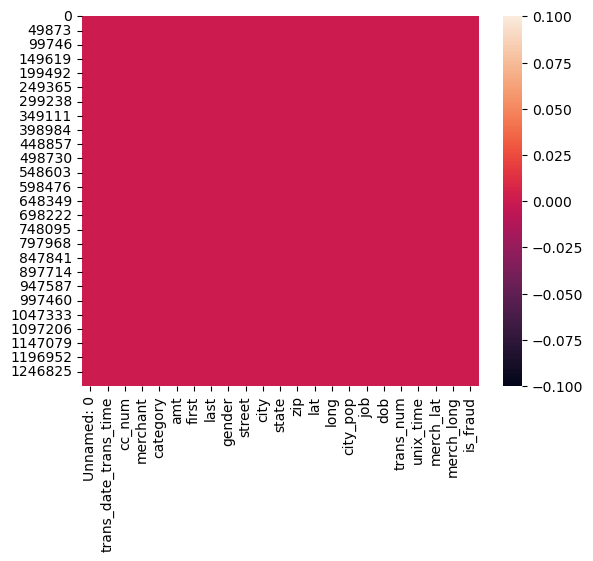

In [9]:
sns.heatmap(data.isnull())

<b>Technical Insight</b><br>
No major missing values detected.<br>
<b>Technical Conclusion</b><br>
Dataset quality is high.<br>
Minimal preprocessing required for:
- Imputation
- Null handling
- Record removal
<b>Business Insight</b><br>
High-quality transactional systems:
- maintain complete financial records
- improve fraud monitoring reliability

# Target Variable Distribution (Fraud vs Normal)

### Basic Counts

In [10]:
print(data["is_fraud"].value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


This gives:
- Total fraud transactions
- Total normal transactions

<b>Technical Insight<b><br>
This confirms:
- Fraud is extremely rare
- Dataset is highly skewed
- Binary classification imbalance exists
<b>Business Insight</b><br>
Most banking transactions are legitimate, while fraud events represent only a tiny fraction of overall financial activity.

### Fraud Percentage

In [11]:
fraud_percent = (data["is_fraud"].value_counts(normalize=True) * 100)
print(fraud_percent)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


This converts raw counts into:
- Interpretable percentages
- Business-level understanding<br>

<b>Technical Insight</b><br>
Fraud transactions account for:
- only ~0.58%
- severe imbalance problem

<b>Business Insight</b><br>
Even though fraud volume is low, financial institutions must detect these rare anomalies because they carry disproportionately high financial risk.

### Fraud vs Normal Transactions

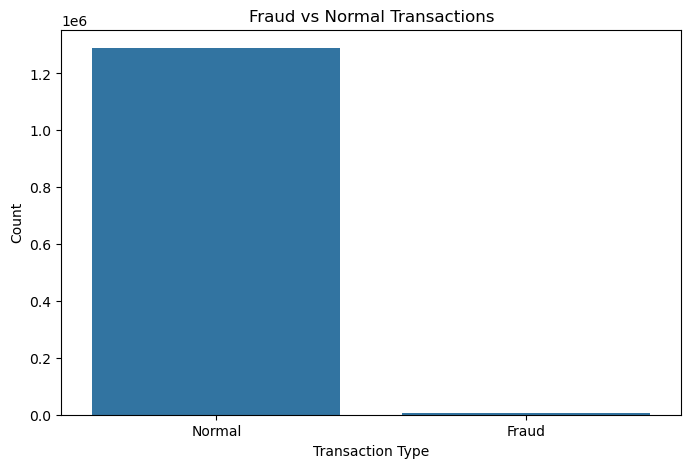

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x=data["is_fraud"],)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks([0,1], ["Normal", "Fraud"])
plt.show()

Visually confirms:
- huge dominance of normal transactions
- very small fraud population

<b>Technical Interpretation</b><br>
The countplot highlights:
- Severe class imbalance
- Need for imbalance-aware ML techniques
- Risk of biased model learning

<b>Business Interpretation</b></br>
Fraud detection systems operate in environments where fraudulent behavior is extremely uncommon but financially dangerous.

### Fraud Transaction Distributions

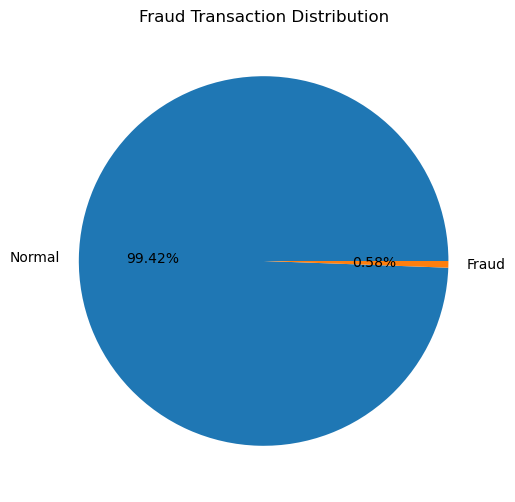

In [13]:
fraud_counts = data["is_fraud"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(fraud_counts,labels=["Normal", "Fraud"],autopct="%1.2f%%",)
plt.title("Fraud Transaction Distribution")
plt.show()

<b>Technical Insight</b><br>
The pie chart emphasizes:
- Fraud rarity
- Skewed class proportions
- Imbalance severity

<b>Business Insight</b><br>
A small percentage of fraud can still result in:
- Major banking losses
- Chargebacks
- Customer dissatisfaction
- Reputational damage

### Summary

In [15]:
normal_count = data["is_fraud"].value_counts()[0]
fraud_count = data["is_fraud"].value_counts()[1]
fraud_ratio = (fraud_count / len(data)) * 100
print(f"Normal Transactions : {normal_count:,}")
print(f"Fraud Transactions  : {fraud_count:,}")
print(f"Fraud Ratio         : {fraud_ratio:.4f}%")

Normal Transactions : 1,289,169
Fraud Transactions  : 7,506
Fraud Ratio         : 0.5789%


### Conclusion
TThe target variable analysis revealed severe class imbalance, with fraudulent transactions accounting for less than 1% of the dataset. Such imbalance can bias machine learning models toward the majority class. Therefore, specialized techniques including SMOTE, class weighting, threshold optimization, ensemble learning, and PR-AUC-based evaluation were necessary to improve fraud detection performance.

# Transaction Amount Analysis

### Basic Statistics

In [16]:
print(data["amt"].describe())

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64


<b>Technical Insights</b><br>
Distribution Characteristics
| Metric | Observation|
|---|---|
|Mean|~70|
|Median||~47|
|Max| ~28948|
|Std Dev|Very high|

Interpretation
Mean > Median

This indicates:
- positively skewed distribution
- presence of large transaction outliers
- Huge Maximum Value

The dataset contains:
- extremely high-value transactions
- strong outliers

Indicates:
- wide variability
- unstable spread
- non-normal distribution
<b>Business Insights</b><br>
Most customer transactions are:
- small-to-medium purchases

But some transactions involve:
- very large spending spikes

These high-value transactions may:
- represent luxury purchases
- business expenses
- potential fraudulent activity

### Compare Fraud vs Normal Amounts

In [17]:
fraud_amt = data[data["is_fraud"] == 1]["amt"]
normal_amt = data[data["is_fraud"] == 0]["amt"]
print("Fraud Amount Statistics")
print(fraud_amt.describe())
print("\nNormal Amount Statistics")
print(normal_amt.describe())

Fraud Amount Statistics
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64

Normal Amount Statistics
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64


<b>Key Findings</b><br>
Fraud Transactions
|Metric|Value|
|---|---|
|Mean|~531|
|Median|~396|
|75%|	~900|
Normal Transactions
|Metric|Value|
|---|---|
|Mean|~67|
|Median|~47|
|75%|	~82|
<b>Technical Insight</b><br>
Fraudulent transactions have:
- significantly higher average amount
- much larger median values
- broader spread

This strongly suggests:
Transaction amount is a highly predictive fraud feature.

ML Interpretation
This means:
- amount will likely become high SHAP importance
- tree models will split heavily on amount
- fraud probability rises with larger amounts

<b>Business Insight</b><br>
Fraudsters tend to:
- maximize stolen card value
- perform larger transactions quickly
- exploit cards before they get blocked

This explains why fraud transactions are substantially larger than normal purchases.

### Transaction Amount Distributions

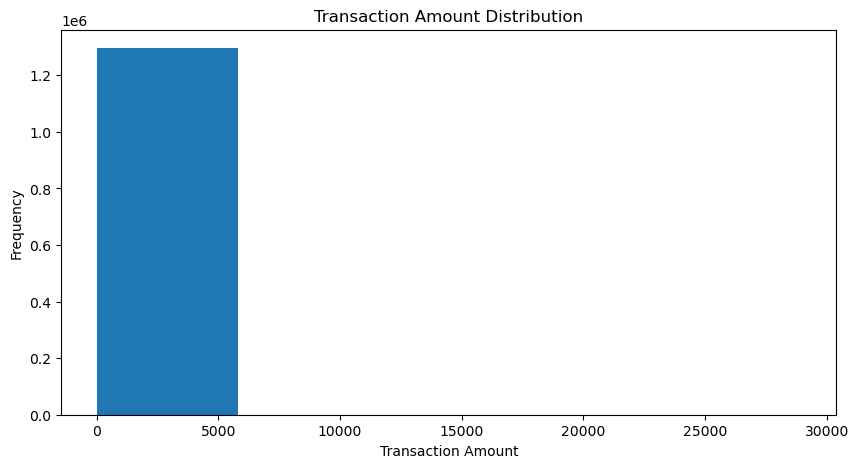

In [18]:
plt.figure(figsize=(10,5))
plt.hist(data["amt"],bins=5)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

<b>Technical Insight</b><br>
The distribution is:
- heavily right-skewed
- non-Gaussian
- long-tailed

This creates:
- scaling challenges
- poor visualization
- unstable ML learning

<b>ML Conclusion</b><br>
This justifies:
- log transformation
- robust scaling
- tree-based algorithms

<b>Business Insight</b><br>
Most customers perform:
- low-value everyday transactions

Very large transactions are:
- rare events
- potentially risky behavior

### Log Transformed Transaction Amount

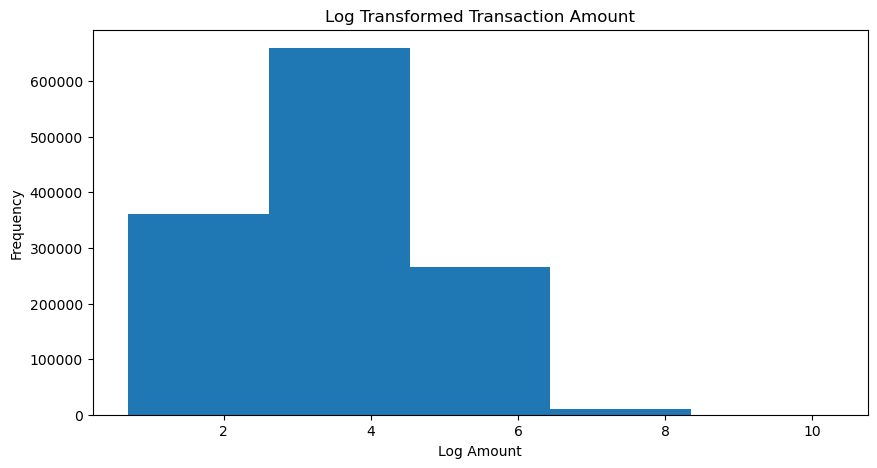

In [19]:
data["amt_log"] = np.log1p(data["amt"])
plt.figure(figsize=(10,5))
plt.hist(data["amt_log"],bins=5)
plt.title("Log Transformed Transaction Amount")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

<b>Technical Insight</b><br>
The transformed distribution becomes:
- more normalized
- less skewed
- easier for ML models to learn

This improves:
- neural network stability
- feature scaling
-convergence

<b>ML Insight</b><br>
Without log transformation:
- ANN models may struggle
- gradients may explode
- large values dominate learning

With log transformation:
- distribution becomes smoother
- model learns patterns better

<b>Business Interpretation</b><br>
Log scaling compresses extremely large transactions while preserving fraud behavior patterns.<br>
This allows:
- better anomaly understanding
- fairer transaction comparison

### Fraud vs Normal Transaction Amount

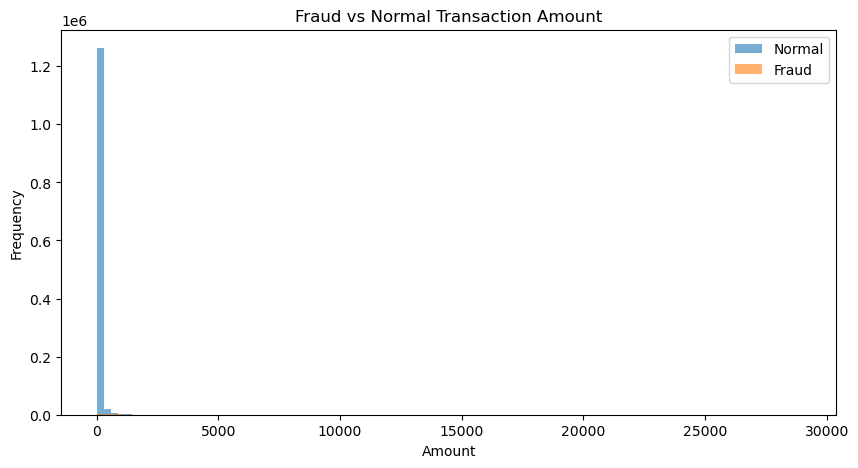

In [20]:
plt.figure(figsize=(10,5))
plt.hist(normal_amt,bins=100,alpha=0.6,label="Normal")
plt.hist(fraud_amt,bins=5,alpha=0.6,label="Fraud")
plt.legend()
plt.title("Fraud vs Normal Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

<b>Technical Insight</b><br>
The fraud distribution is shifted toward:
- higher transaction amounts

Normal transactions cluster heavily at:
- low amounts

This visually confirms:
- amount is a strong fraud discriminator

<b>Business Insight</b><br>
Fraudulent behavior is associated with:
- unusually large purchases
- abnormal spending intensity

### Transaction Amount by Fraud Class (BoxPlot)

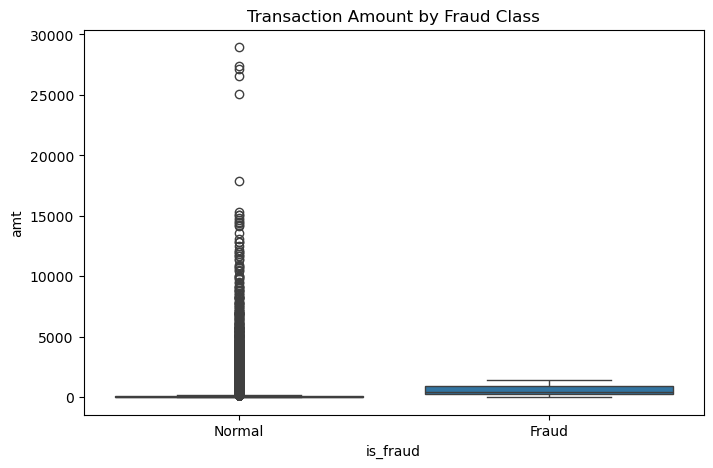

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud",y="amt",data=data)
plt.xticks([0,1],["Normal", "Fraud"])
plt.title("Transaction Amount by Fraud Class")
plt.show()

<b>Technical Insight</b><br>
The boxplot reveals:
Normal Transactions
- many extreme outliers
- low median
- compact interquartile range

Fraud Transactions
- consistently higher transaction amounts
- higher median
- tighter concentration at elevated values

<b>Important Observation</b><br>
Fraud transactions are not only high — they are consistently high.<br>
This is more valuable than just detecting outliers.

<b>ML Insight</b><br>
This indicates:
- amount distributions differ structurally
- models can separate classes effectively

<b>Business Insight</b><br>
Fraudsters exhibit:
- abnormal spending patterns
- unusually elevated transaction behavior
- compared to genuine users.

### Amount Percentiles

In [22]:
print(data["amt"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

0.50     47.5200
0.75     83.1400
0.90    136.6700
0.95    196.3100
0.99    545.9926
Name: amt, dtype: float64


<b>Interpretation</b><br>
Most transactions are relatively small.

Only a tiny fraction exceed:
- 500+
- high-value territory

<b>Business Insight</b><br>
Transactions above higher percentiles may require:
- enhanced fraud monitoring
- additional authentication
- risk scoring adjustments

### High Amount Fraud Rate

In [23]:
high_amt = data[data["amt"] > 1000]
fraud_rate = (high_amt["is_fraud"].mean()) * 100
print(f"Fraud rate for transactions > $1000: {fraud_rate:.2f}%")

Fraud rate for transactions > $1000: 24.11%


<b>Technical Insight</b><br>
Although overall fraud rate is:
- only 0.58%
- transactions above $1000 show: ~24% fraud probability

This means:
- conditional fraud probability increases dramatically with amount

<b>Important Fraud Insight</b><br>
High-value transactions are disproportionately associated with fraud.

<b>Business Interpretation</b><br>
Large transactions should trigger:
- real-time fraud scoring
- OTP verification
- transaction review
- behavioral analysis<br>

because financial risk rises sharply.

# Conclusion
Transaction amount analysis revealed that fraudulent transactions are significantly larger than normal transactions. The amount feature exhibited strong positive skewness with multiple extreme outliers, making log transformation necessary for improved machine learning performance. Fraud transactions showed substantially higher average and median values, indicating that fraudsters tend to perform high-value purchases. Additionally, transactions above $1000 demonstrated a dramatically higher fraud rate, confirming transaction amount as one of the strongest predictors of fraudulent behavior.

# Time Based Analysis

### Convert DateTime

In [24]:
data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"])

### Extract Time Features

In [25]:
data["hour"] = data["trans_date_trans_time"].dt.hour
data["day_of_week"] = (data["trans_date_trans_time"].dt.day_name())
data["month"] = (data["trans_date_trans_time"].dt.month_name())
data["is_weekend"] = (data["trans_date_trans_time"].dt.weekday >= 5).astype(int)
data["is_night"] = ((data["hour"] < 6)| (data["hour"] > 22)).astype(int)

### Fraud Rate by Hour

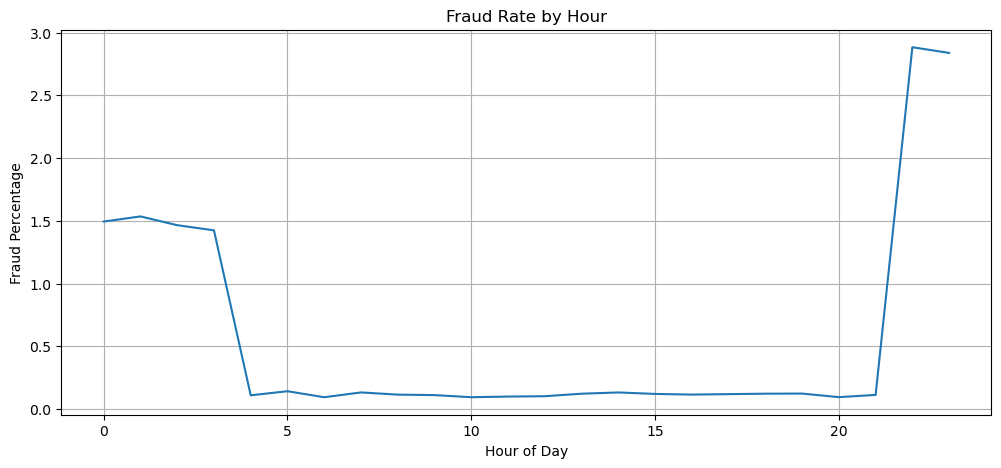

In [26]:
hourly_fraud = (data.groupby("hour")["is_fraud"].mean() * 100)
plt.figure(figsize=(12,5))
hourly_fraud.plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage")
plt.grid(True)
plt.show()

<b>Key Finding</b><br>
Fraud spikes heavily during:
- late night hours
- around 22–23 hours
- early midnight hours
- while daytime fraud remains very low.

<b>Technical Insight</b><br>
The graph clearly shows:
- fraud is not uniformly distributed
- nighttime activity has elevated fraud probability

This indicates:
- temporal fraud concentration

<b>ML Interpretation</b>
This means:
- Hour of transaction is a predictive feature.

Models will likely learn:
- higher fraud probability at night
- lower fraud probability during daytime
- Tree models especially benefit from this pattern.

<b>Business Insight</b><br>
Fraudsters commonly attack during:
- reduced human monitoring
- low customer awareness periods
- sleeping hours

because:
- victims respond slowly
- fraud alerts may go unnoticed
- banks may have delayed intervention

<b>IMPORTANT Observation</b><br>
fraud rate reaches nearly:
- equivalent to 3% during late-night hours.

Compare this to overall fraud rate: 0.58%<br>
This is a MASSIVE increase.

<b>Important Fraud Conclusion</b><br>
Nighttime transactions are significantly riskier than daytime transactions.

### Transaction Count By Hour

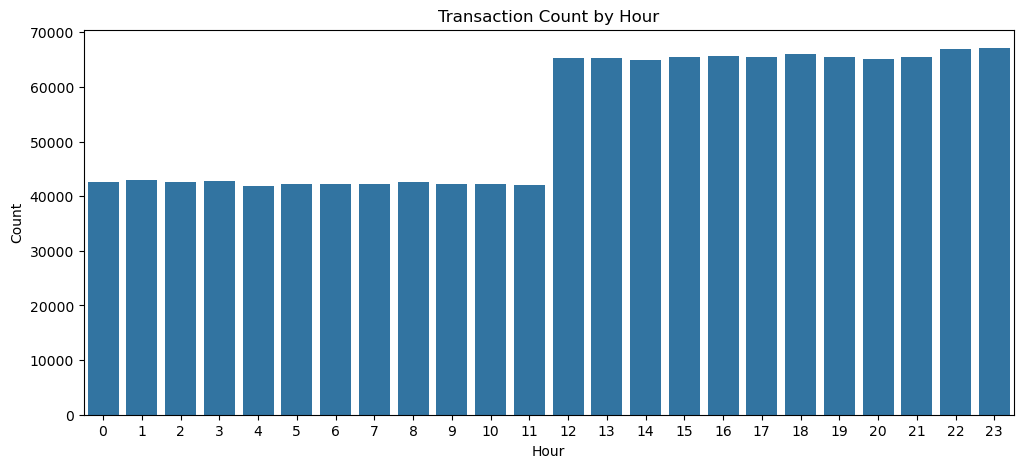

In [27]:
plt.figure(figsize=(12,5))
sns.countplot(x="hour",data=data)
plt.title("Transaction Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

<b>Key Observation</b><br>
Transaction volume is:
- relatively stable
- slightly higher during later hours<br>
But fraud rate behavior differs sharply.

<b>Important Insight</b><br>
High fraud rate is NOT simply because:
- more transactions happen

Instead:
- fraud concentration itself increases

This is very important analytically.

<b>Business Interpretation</b><br>
The increase in fraud risk at night reflects:
- behavioral fraud targeting
- intentional timing strategies

rather than normal transaction traffic.

### Fraud Rate by Day

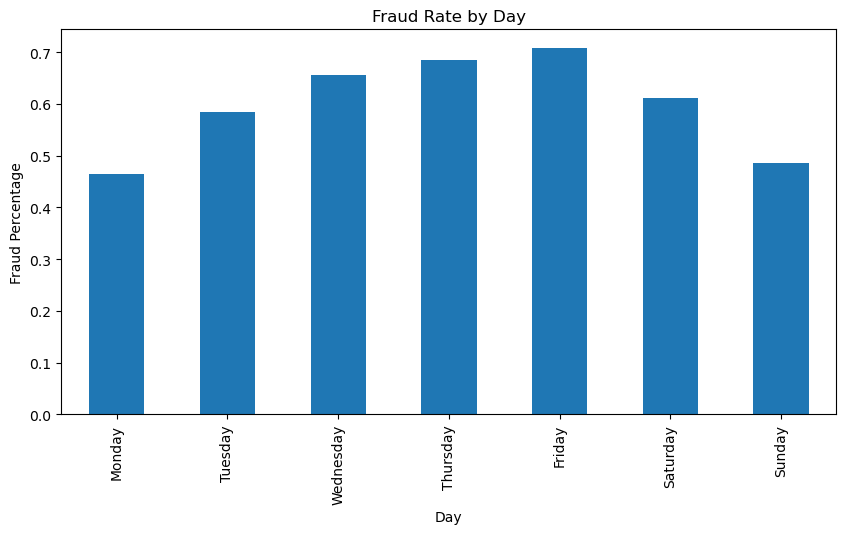

In [28]:
day_fraud = (data.groupby("day_of_week")["is_fraud"].mean() * 100)
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_fraud = day_fraud.reindex(day_order)
plt.figure(figsize=(10,5))
day_fraud.plot(kind="bar")
plt.title("Fraud Rate by Day")
plt.xlabel("Day")
plt.ylabel("Fraud Percentage")
plt.show()

<b>Key Finding</b><br>
Fraud increases toward:
- Thursday
- Friday

and decreases on:
- Monday
- Sunday

<b>Technical Interpretation</b><br>
Fraud activity varies across weekdays.

This indicates:
- weekly behavioral cycles
- organized fraud timing patterns

Possible Real-World Reasons<br>
Fraudsters may target:
- end-of-week shopping activity
- salary periods
- high transaction days
- reduced monitoring before weekends

<b>ML Insight</b>
Day-of-week becomes:
- a moderate predictive feature

Especially useful in:
- boosting models
- ensemble trees

### Weekend vs Weekday

In [29]:
weekend_fraud = (data.groupby("is_weekend")["is_fraud"].mean() * 100)
print(weekend_fraud)

is_weekend
0    0.599073
1    0.541042
Name: is_fraud, dtype: float64


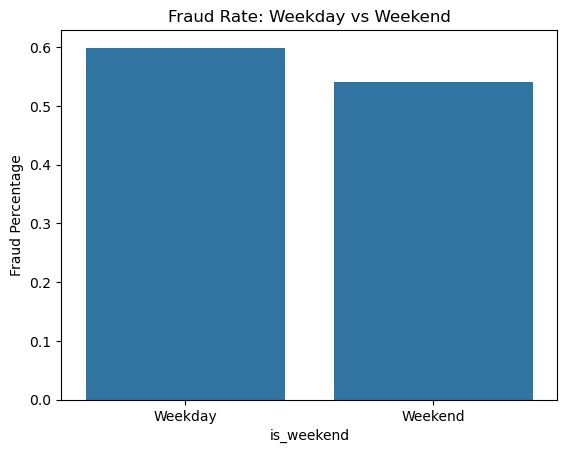

In [30]:
sns.barplot(x=weekend_fraud.index,y=weekend_fraud.values)
plt.xticks([0,1],["Weekday", "Weekend"])
plt.title("Fraud Rate: Weekday vs Weekend")
plt.ylabel("Fraud Percentage")
plt.show()

<b>Observation</b><br>
Weekday fraud rate:
- slightly higher than weekend

Difference is small but noticeable.

<b>Interpretation</b>
This suggests:
- fraud occurs consistently
- but operational/business weekday activity slightly increases risk exposure

<b>Business Interpretation</b><br>
Weekdays usually have:
- higher transaction intensity
- commercial activity
- online payment volume

creating:
- larger fraud opportunity windows

### Monthly Fraud Trends

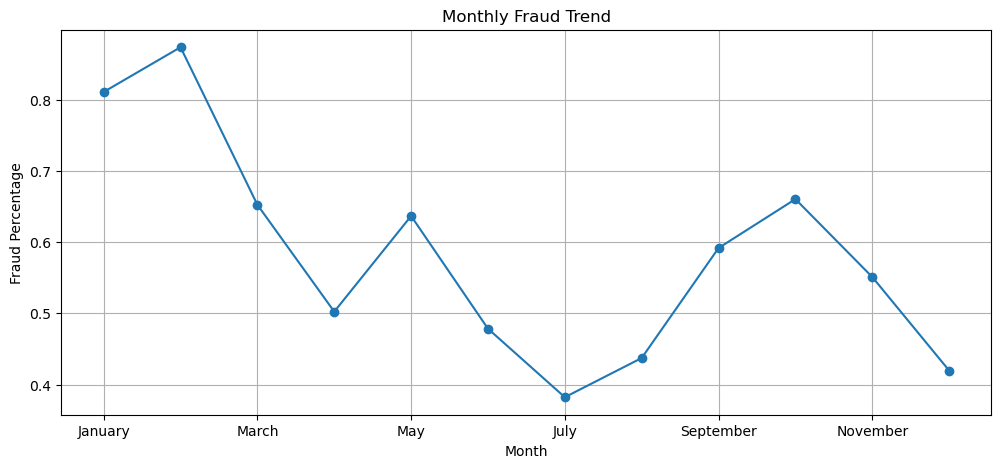

In [31]:
monthly_fraud = (data.groupby("month")["is_fraud"].mean() * 100)
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_fraud = monthly_fraud.reindex(month_order)
plt.figure(figsize=(12,5))
monthly_fraud.plot(kind="line", marker="o")
plt.title("Monthly Fraud Trend")
plt.xlabel("Month")
plt.ylabel("Fraud Percentage")
plt.grid(True)
plt.show()

<b>Key Findings</b><br>
Fraud rates fluctuate significantly across months.

Higher fraud months:
- January
- February
- October

Lower fraud months:
- July
- December

Possible Explanations<br>
January-February

Possible causes:
- holiday aftermath fraud
- stolen card exploitation
- refund abuse
- e-commerce activity

October<br>
Could indicate:
- seasonal shopping increase
- festival-related fraud spikes

Important Caution<br>
Monthly trends may also reflect:
- dataset sampling behavior
- temporal imbalance


Seasonal fraud variations may indicate changing customer behavior and fraudster activity patterns throughout the year.

### Day vs Hour (Heatmap)

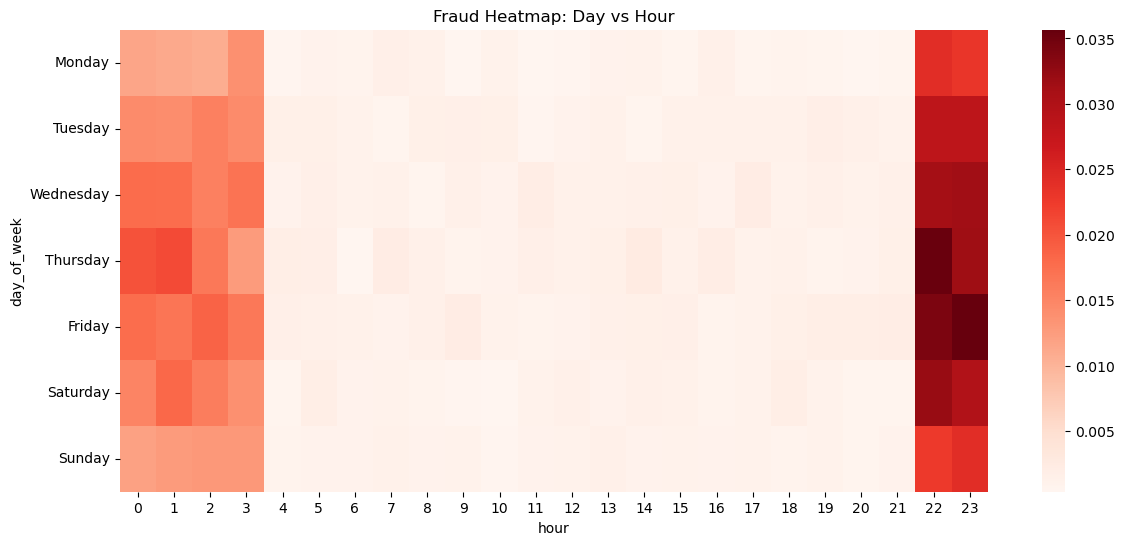

In [32]:
heatmap_data = pd.pivot_table(data,values="is_fraud",index="day_of_week",columns="hour",aggfunc="mean")
heatmap_data = heatmap_data.reindex(day_order)
plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data,cmap="Reds")
plt.title("Fraud Heatmap: Day vs Hour")
plt.show()

<b>Key Findings</b><br>
Highest fraud intensity occurs:
- late night (22–23)
- early morning (0–3)

especially:
- Thursday
- Friday

<b>Technical Interpretation</b><br>
Fraud patterns show:
- temporal clustering
- coordinated behavior
- concentrated attack windows

This is highly valuable for:
- anomaly detection
- real-time monitoring systems

<b>Business Interpretation</b><br>
Banks and payment systems should:
- increase monitoring during high-risk hours
- apply stricter fraud scoring at night
- use adaptive authentication mechanisms
- during identified risk windows.

<b>ML Insight</b><br>
The heatmap suggests strong interaction effects between:
- hour
- weekday

This means:
combined temporal features may improve model performance.

# Conclusion
Time-based analysis revealed strong temporal fraud patterns across hours, weekdays, and months. Fraud activity was significantly higher during late-night hours and early morning periods, with the highest fraud concentration observed around 22:00–23:00. Fraud rates also varied across weekdays, peaking near the end of the week, while seasonal monthly fluctuations suggested changing fraud behavior over time. The heatmap analysis further confirmed that fraudulent transactions are temporally clustered rather than randomly distributed. These findings indicate that temporal features such as transaction hour, weekday, weekend status, and seasonal trends are valuable predictors for fraud detection models.

# Merchant & Category Fraud Analysis 

### Top Fraudulent Merchants

In [33]:
top_fraud_merchants = (data[data["is_fraud"] == 1]["merchant"].value_counts().head(10))
print(top_fraud_merchants)

merchant
fraud_Rau and Sons       49
fraud_Cormier LLC        48
fraud_Kozey-Boehm        48
fraud_Doyle Ltd          47
fraud_Vandervort-Funk    47
fraud_Kilback LLC        47
fraud_Padberg-Welch      44
fraud_Kuhn LLC           44
fraud_Terry-Huel         43
fraud_Koepp-Witting      42
Name: count, dtype: int64


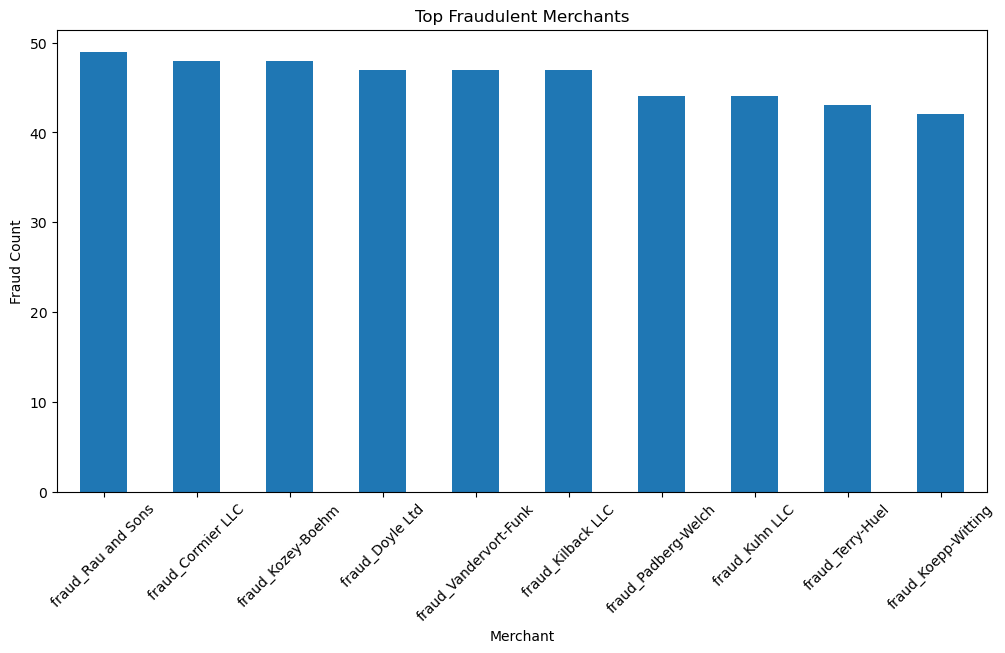

In [34]:
plt.figure(figsize=(12,6))
top_fraud_merchants.plot(kind="bar")
plt.title("Top Fraudulent Merchants")
plt.xlabel("Merchant")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.show()

<b>Key Observation</b><br>
Certain merchants repeatedly appear in fraudulent activity.

Examples:
- fraud_Rau and Sons
- fraud_Cormier LLC
- fraud_Kozey-Boehm

<b>Analytical Insight</b><br>
This suggests:
- Fraud is concentrated around specific merchant entities.

Possible reasons:
- weak merchant security
- fake merchant accounts
- compromised merchant systems
- fraudster-preferred merchants

High fraud count alone can be misleading.

A merchant may:
- have high fraud count
- simply because transaction volume is massive

### Merchant Fraud Rate

In [35]:
merchant_fraud_rate = (data.groupby("merchant")["is_fraud"].mean() * 100)
top_risky_merchants = (merchant_fraud_rate.sort_values(ascending=False).head(10))
print(top_risky_merchants)

merchant
fraud_Kozey-Boehm                       2.572347
fraud_Herman, Treutel and Dickens       2.538462
fraud_Kerluke-Abshire                   2.230686
fraud_Brown PLC                         2.210884
fraud_Goyette Inc                       2.161606
fraud_Terry-Huel                        2.154309
fraud_Jast Ltd                          2.150538
fraud_Schmeler, Bashirian and Price     2.083333
fraud_Boyer-Reichert                    1.991614
fraud_Langworth, Boehm and Gulgowski    1.980701
Name: is_fraud, dtype: float64


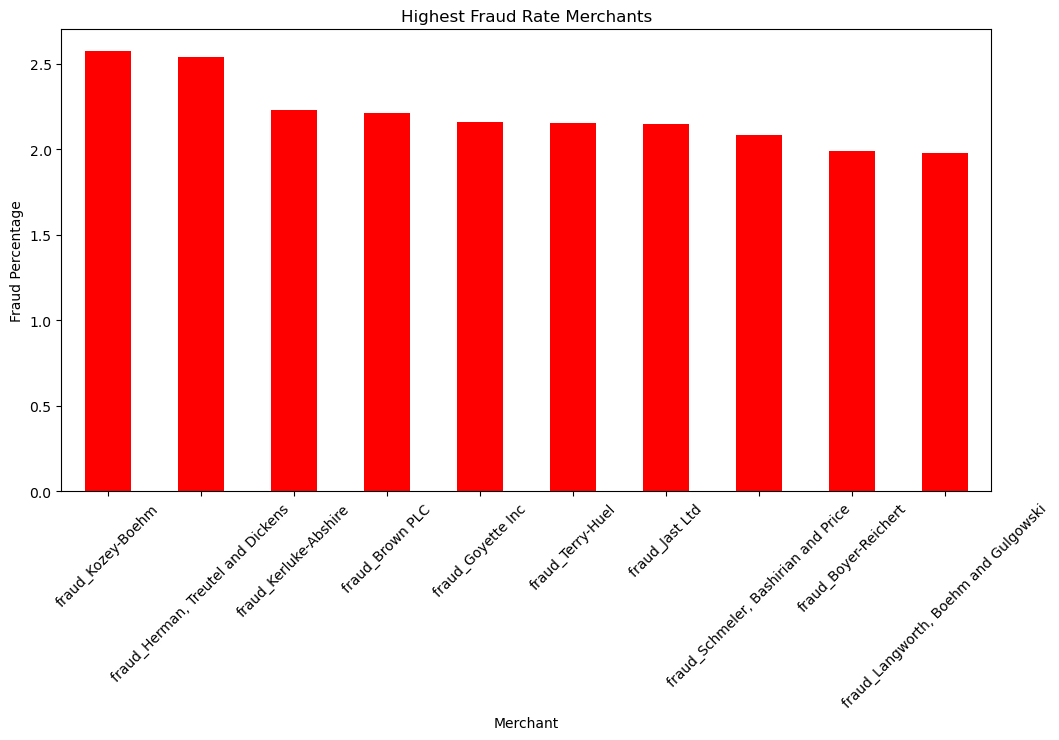

In [36]:
plt.figure(figsize=(12,6))
top_risky_merchants.plot(kind="bar", color="red")
plt.title("Highest Fraud Rate Merchants")
plt.xlabel("Merchant")
plt.ylabel("Fraud Percentage")
plt.xticks(rotation=45)
plt.show()

<b>Key Findings</b><br>
Some merchants exceed:
- 2.5% fraud rate

Compare with overall dataset fraud rate:
- ~0.58%

This means these merchants are:
- 4–5x riskier than average.

Real-World Interpretation

High-risk merchants may indicate:

- compromised merchant infrastructure
- fraud-targeted merchant categories
- synthetic merchants
- mule operations
- card testing locations
<b>Business Insight</b><>br
Banks could:
- increase fraud scrutiny for these merchants
- require additional authentication
- apply adaptive fraud thresholds
- temporarily block suspicious merchant activity

### Transaction Category Analysis

In [37]:
category_fraud_count = (data[data["is_fraud"] == 1]["category"].value_counts())
print(category_fraud_count)

category
grocery_pos       1743
shopping_net      1713
misc_net           915
shopping_pos       843
gas_transport      618
misc_pos           250
kids_pets          239
entertainment      233
personal_care      220
home               198
food_dining        151
grocery_net        134
health_fitness     133
travel             116
Name: count, dtype: int64


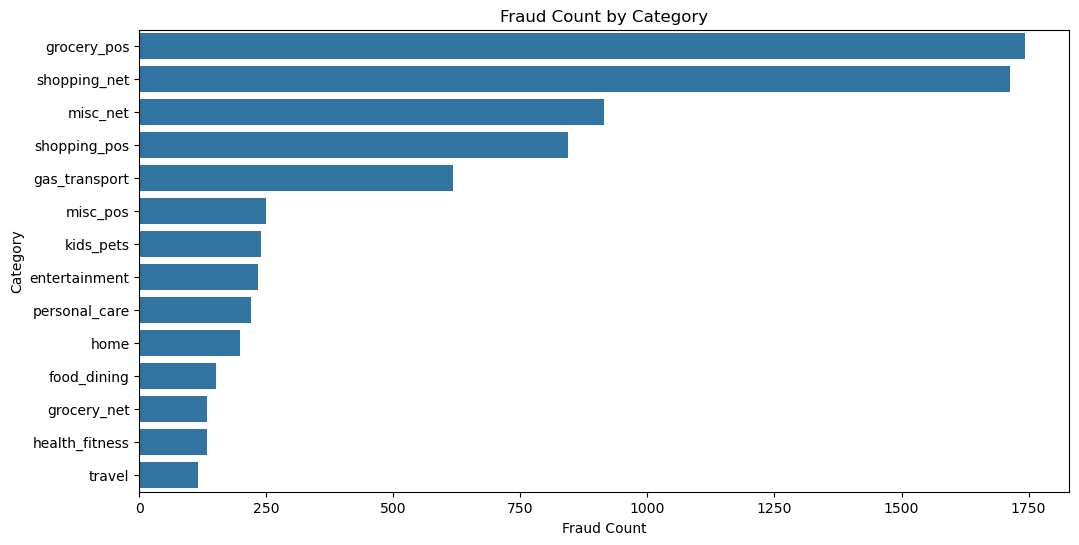

In [38]:
plt.figure(figsize=(12,6))
sns.countplot(y="category",data=data[data["is_fraud"] == 1],order=data[data["is_fraud"] == 1]["category"].value_counts().index)
plt.title("Fraud Count by Category")
plt.xlabel("Fraud Count")
plt.ylabel("Category")
plt.show()

<b>Key Findings</b><br>
Highest fraud counts occur in:
- grocery_pos
- shopping_net
- misc_net
- shopping_pos

<b>Interpretation</b><br>
Fraudsters heavily target:
- online shopping
- POS systems
-high-frequency consumer categories

<b>Business Explanation</b><br>

These categories:
- process large transaction volumes
- have lower friction
- allow faster fraud execution

especially:
- e-commerce categories

Online categories:
- shopping_net
- misc_net

show strong fraud presence.

This aligns with:
- real-world card-not-present fraud patterns.

Real Fraud Domain Insight<br>
Card-not-present fraud is one of the largest fraud categories globally.

Because:
- physical card verification absent
- easier credential theft exploitation
- remote transaction abuse

### Fraud Rate by Category

In [39]:
category_fraud_rate = (data.groupby("category")["is_fraud"].mean() * 100)
category_fraud_rate = (category_fraud_rate.sort_values(ascending=False))
print(category_fraud_rate)

category
shopping_net      1.756149
misc_net          1.445795
grocery_pos       1.409761
shopping_pos      0.722538
gas_transport     0.469394
misc_pos          0.313853
grocery_net       0.294817
travel            0.286370
entertainment     0.247835
personal_care     0.242403
kids_pets         0.211439
food_dining       0.165098
home              0.160825
health_fitness    0.154869
Name: is_fraud, dtype: float64


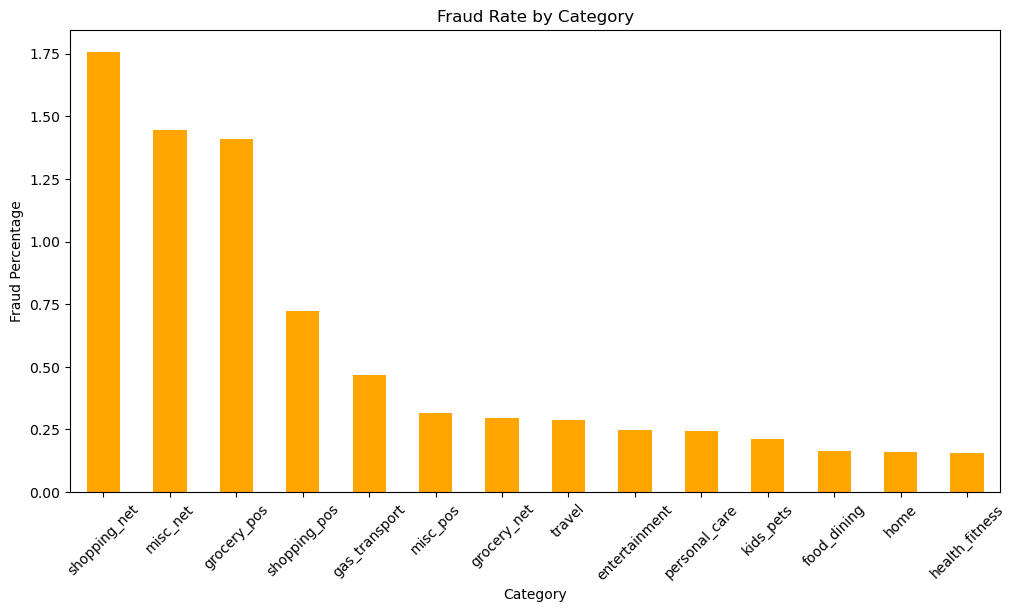

In [40]:
plt.figure(figsize=(12,6))
category_fraud_rate.plot(kind="bar",color="orange")
plt.title("Fraud Rate by Category")
plt.xlabel("Category")
plt.ylabel("Fraud Percentage")
plt.xticks(rotation=45)
plt.show()

<b>Key Findings</b><br>
Highest fraud rates:
- shopping_net
- misc_net
- grocery_pos

<b>Interpretation</b><br>
These categories are not only:
- large fraud volume categories

but also:
- intrinsically riskier categories.

<b>Technical Insight</b><br>
Fraud rate analysis helps identify:
- vulnerable transaction ecosystems

rather than:
- simply popular categories.
Key Risk Observation
- shopping_net has the highest fraud percentage.

This is a highly realistic result.

Why Online Shopping Is Risky

E-commerce fraud increases because:
- no physical verification
- stolen cards easier to use
- fake shipping identities
- rapid automated purchases
- bot-driven fraud attacks


Real fraud detection systems often assign:
- category risk scores

Example:<br>
shopping_net → high risk<br>
travel → medium risk<br>
health_fitness → low risk<br>

### Category-wise Fraud vs Normal Transactions

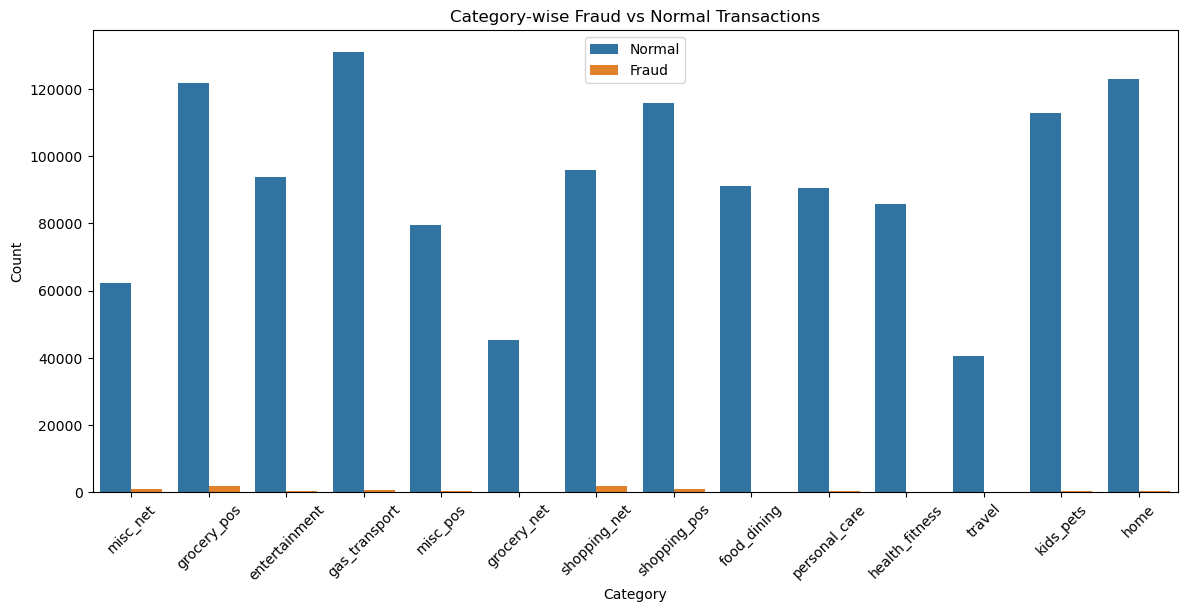

In [41]:
plt.figure(figsize=(14,6))
sns.countplot(data=data,x="category",hue="is_fraud")
plt.title("Category-wise Fraud vs Normal Transactions")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Normal", "Fraud"])
plt.show()

<b>Observation<b><br>
Some categories:
- have huge normal transaction volume
- but relatively small fraud

while others:
- show elevated fraud concentration.

<b>ML Insight</b><br>
This indicates:
- category variable contains predictive information

Useful for:
- tree models
- boosting
- target encoding
- fraud scoring systems

### Transaction Volume Merchants

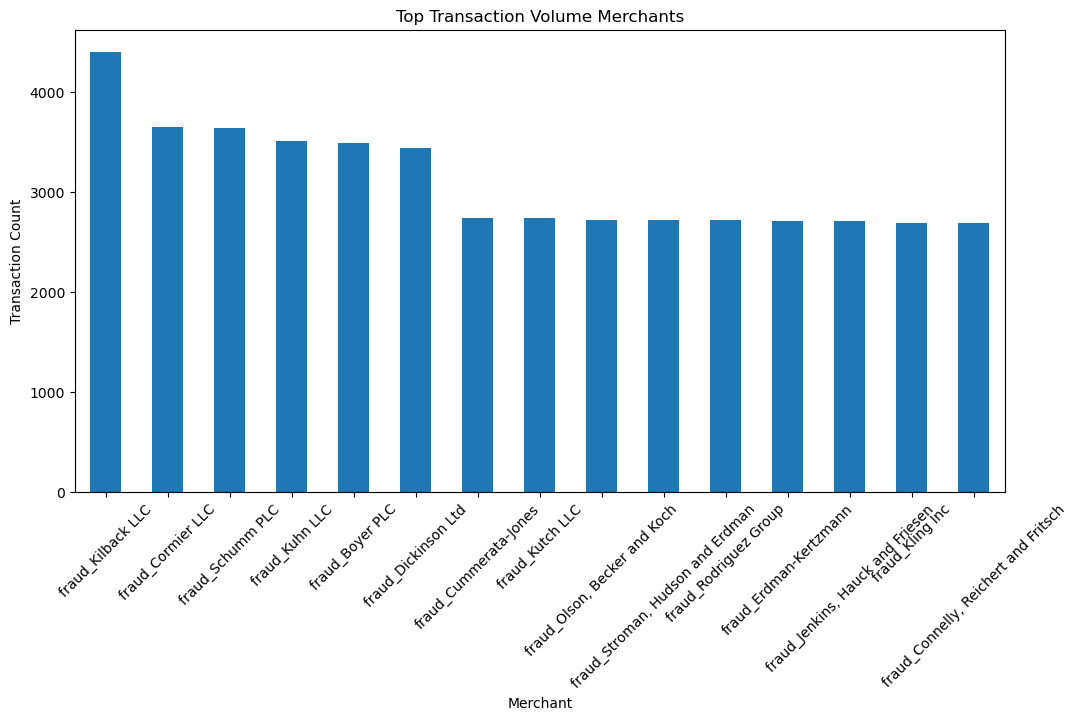

In [42]:
top_merchants = (data["merchant"].value_counts().head(15))
plt.figure(figsize=(12,6))
top_merchants.plot(kind="bar")
plt.title("Top Transaction Volume Merchants")
plt.xlabel("Merchant")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

# Conclusion
Merchant and category analysis revealed that fraudulent transactions are concentrated within specific merchants and transaction categories. While some merchants showed high fraud counts due to large transaction volumes, fraud rate analysis identified several merchants with significantly elevated fraud probabilities. Category-level analysis showed that online shopping and miscellaneous online transaction categories experienced the highest fraud rates, indicating increased vulnerability in card-not-present transactions. Comparative analysis between normal and fraudulent transactions further demonstrated that fraud distribution varies substantially across transaction ecosystems. These findings suggest that merchant identity and transaction category are highly informative predictors for fraud detection systems.

# Geographic Fraud Analysis

### Fraud Count by State

In [43]:
state_fraud_count = (data[data["is_fraud"] == 1]["state"].value_counts().head(15))
print(state_fraud_count)

state
NY    555
TX    479
PA    458
CA    326
OH    321
FL    281
IL    248
MI    238
AL    215
MN    207
VA    198
SC    193
MO    191
NE    180
WI    163
Name: count, dtype: int64


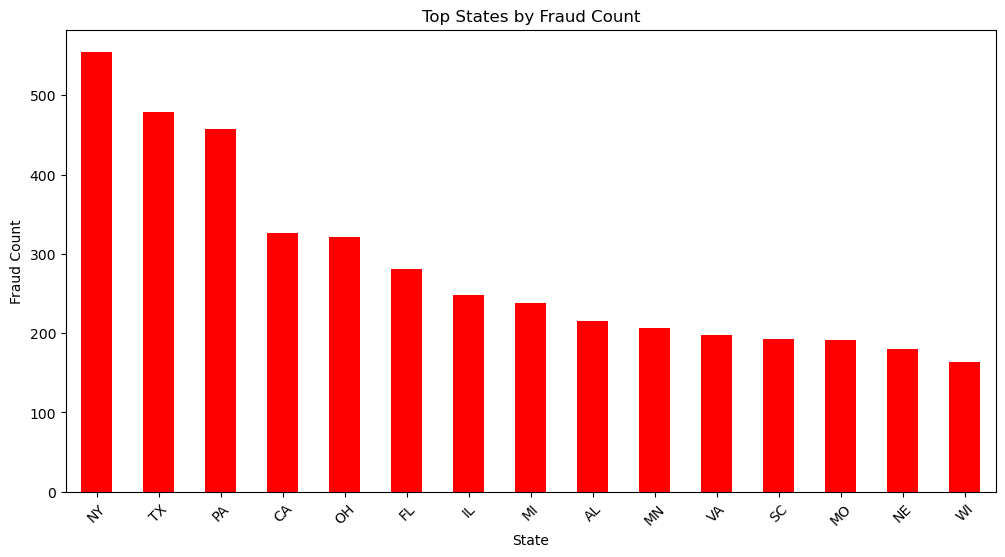

In [44]:
plt.figure(figsize=(12,6))
state_fraud_count.plot(kind="bar",color="red")
plt.title("Top States by Fraud Count")
plt.xlabel("State")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.show()

<b>Key Findings</b><br>
Top fraud count states:
- NY
- TX
- PA
- CA
- OH

<b>Interpretation</b><br>
These states have:
- the highest number of fraudulent transactions

BUT this does NOT necessarily mean:
- they are the riskiest states.

This is the same issue you correctly handled in merchant analysis.

<b>Important Insight</b><br>
Large states naturally have:
- more population
- more transactions
- more fraud opportunities

### Fraud Rate by State

In [45]:
state_fraud_rate = (data.groupby("state")["is_fraud"].mean() * 100)
top_risky_states = (state_fraud_rate.sort_values(ascending=False).head(15))
print(top_risky_states)

state
DE    100.000000
RI      2.727273
AK      1.698113
NV      0.838238
CO      0.814121
OR      0.801204
TN      0.797539
NE      0.744786
ME      0.720994
NH      0.712733
OH      0.690620
KS      0.678379
VA      0.676923
NY      0.664663
SC      0.661185
Name: is_fraud, dtype: float64


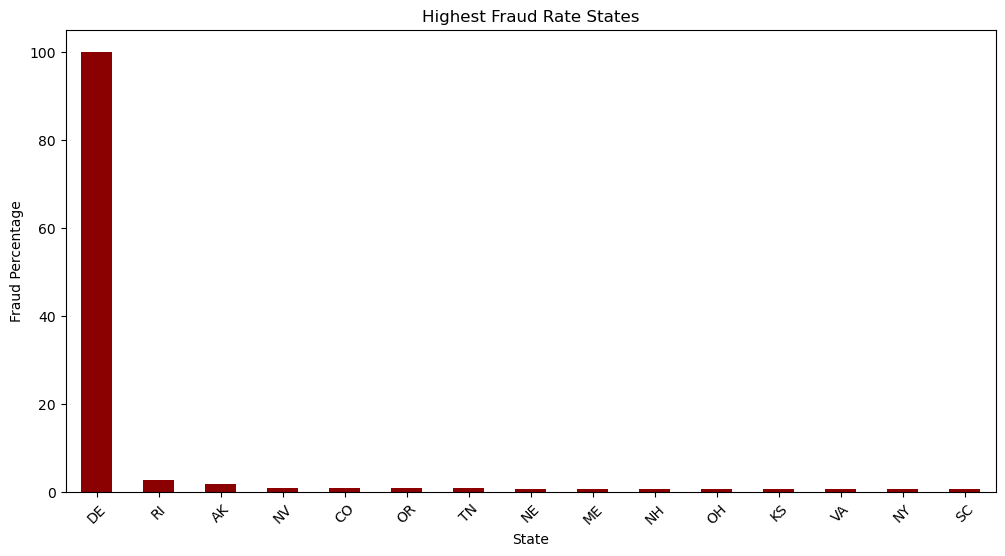

In [46]:
plt.figure(figsize=(12,6))
top_risky_states.plot(kind="bar",color="darkred")
plt.title("Highest Fraud Rate States")
plt.xlabel("State")
plt.ylabel("Fraud Percentage")
plt.xticks(rotation=45)
plt.show()

<b>OBSERVATION</b><br>
DE = 100%

<b>Real-World Interpretation</b><br>
After removing tiny samples:
- states with high fraud rate indicate
- organized fraud activity
- regional fraud vulnerability
- weak verification ecosystems
- high-risk transaction environments

### Fraud by City

In [47]:
city_fraud_count = (data[data["is_fraud"] == 1]["city"].value_counts().head(15))
print(city_fraud_count)

city
Houston         39
Warren          33
Huntsville      29
Naples          29
Dallas          27
Tulsa           27
Topeka          27
Detroit         26
Utica           25
Randolph        25
San Antonio     25
Albuquerque     24
Clearwater      24
Beaver Falls    24
Aurora          23
Name: count, dtype: int64


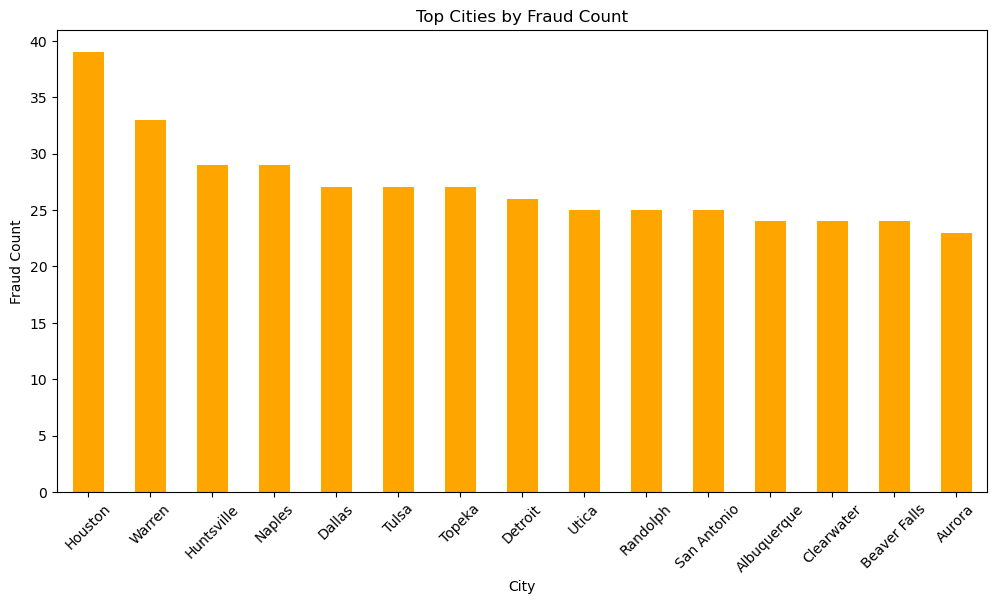

In [48]:
plt.figure(figsize=(12,6))
city_fraud_count.plot(kind="bar",color="orange")
plt.title("Top Cities by Fraud Count")
plt.xlabel("City")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.show()

<b>Key Findings</b><br>
High fraud count cities:
- Houston
- Warren
- Huntsville
- Naples
- Dallas

<b>Interpretation</b><br>

Fraud activity clusters geographically.

This suggests:
- localized fraud ecosystems
- concentrated attack zones
- regional criminal activity

<b>Fraud Intelligence Insight</b><br>
Fraud hotspots may arise due to:
- population density
- transaction volume
- merchant concentration
- organized fraud rings
- regional security weaknesses

<b>Observation</b><br>
Houston and Dallas appearing makes sense because:
- large urban transaction ecosystems
- high card activity
- strong commerce volume

Banks often use:
- geo-risk scoring

Example:
- Houston → medium-high risk
- Dallas → medium risk

based on:
- historical fraud patterns.

### City Fraud Rate

In [49]:
city_fraud_rate = (data.groupby("city")["is_fraud"].mean() * 100)
top_risky_cities = (city_fraud_rate.sort_values(ascending=False).head(15))
print(top_risky_cities)

city
Buellton        100.0
Winnsboro       100.0
Ashland         100.0
Clinton         100.0
Grenola         100.0
East China      100.0
Queen Anne      100.0
Wartburg        100.0
Claypool        100.0
Waukau          100.0
North East      100.0
Lockhart        100.0
Gaines          100.0
Roland          100.0
Mount Vernon    100.0
Name: is_fraud, dtype: float64


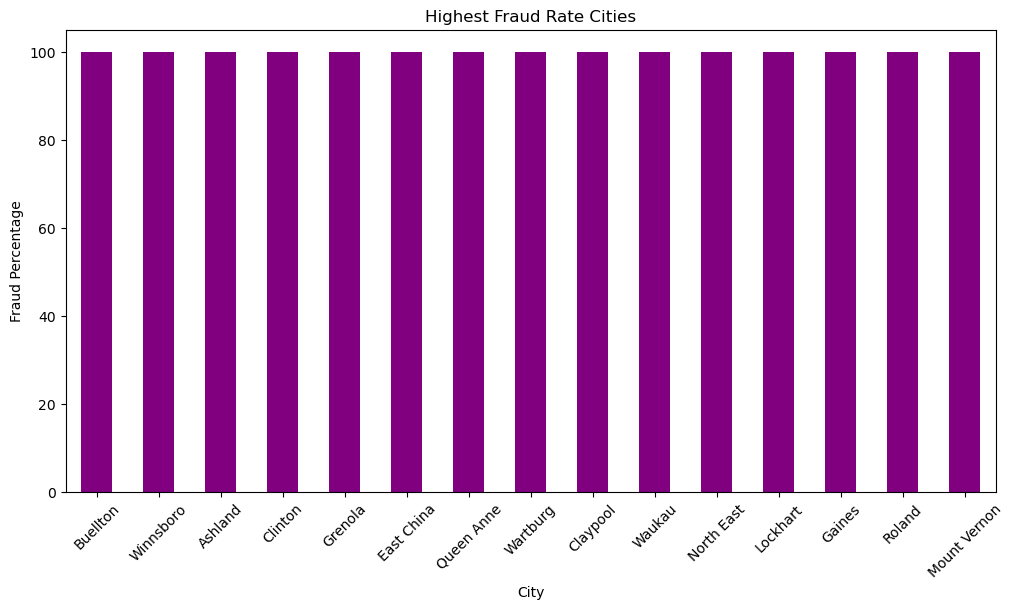

In [50]:
plt.figure(figsize=(12,6))
top_risky_cities.plot(kind="bar",color="purple")
plt.title("Highest Fraud Rate Cities")
plt.xlabel("City")
plt.ylabel("Fraud Percentage")
plt.xticks(rotation=45)
plt.show()

# Conclusion
Geographic fraud analysis revealed significant regional variation in fraudulent transaction behavior. While states such as New York, Texas, and Pennsylvania exhibited the highest fraud counts due to large transaction volumes, fraud rate analysis highlighted the importance of normalizing by transaction activity. Several small-sample regions displayed artificially inflated fraud rates, emphasizing the need for minimum transaction thresholds during geographic risk assessment. City-level analysis further demonstrated that fraud activity clusters geographically, suggesting the existence of localized fraud ecosystems and region-specific transaction vulnerabilities. These findings indicate that geographic information can serve as a valuable predictive signal for fraud detection and risk scoring systems.

# Population Analysis

### Fraud vs Population

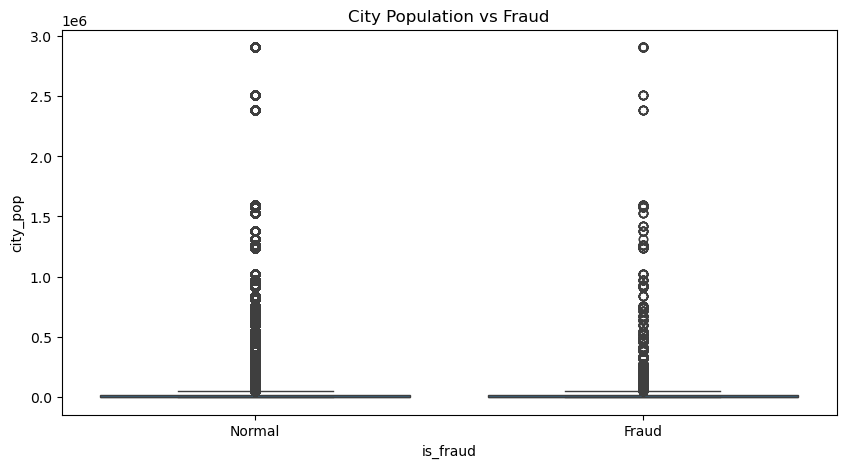

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(x="is_fraud",y="city_pop",data=data)
plt.xticks([0,1],["Normal", "Fraud"])
plt.title("City Population vs Fraud")
plt.show()

<b>Key Observation</b><br>
Your plot shows:
- both fraud and normal transactions occur across:
- small cities
- medium cities
- large cities.
There is NO obvious separation.

<b>Important Insight</b><br>
This suggests:
- City population alone is not a strong fraud discriminator.
- This is a highly valuable EDA conclusion.

<b>Fraud Analytics Interpretation</b><br>
Fraud does NOT exclusively happen in:
- highly populated cities.

Fraud exists across:
- all population scales.

This means:
- fraudsters are geographically distributed
- digital payment systems enable fraud independent of city size.

Data is heavily right-skewed.

You can clearly see:
- many small/medium population cities
- few massive metropolitan outliers.

Examples likely include:
- NYC
- Houston
- LA
- Chicago

This is why:
- your boxplot becomes compressed near the bottom.

### Log Population Distribution

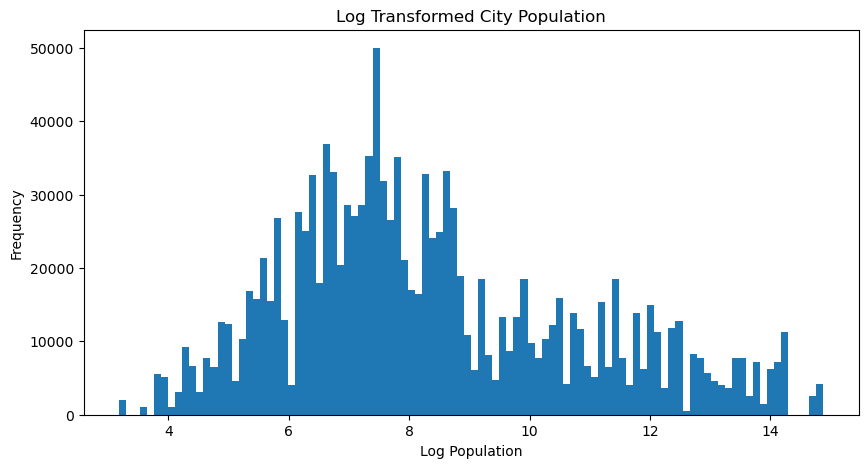

In [52]:
data["city_pop_log"] = np.log1p(data["city_pop"])
plt.figure(figsize=(10,5))
plt.hist(data["city_pop_log"],bins=100)
plt.title("Log Transformed City Population")
plt.xlabel("Log Population")
plt.ylabel("Frequency")
plt.show()

### Geographic Distributions of Transactions

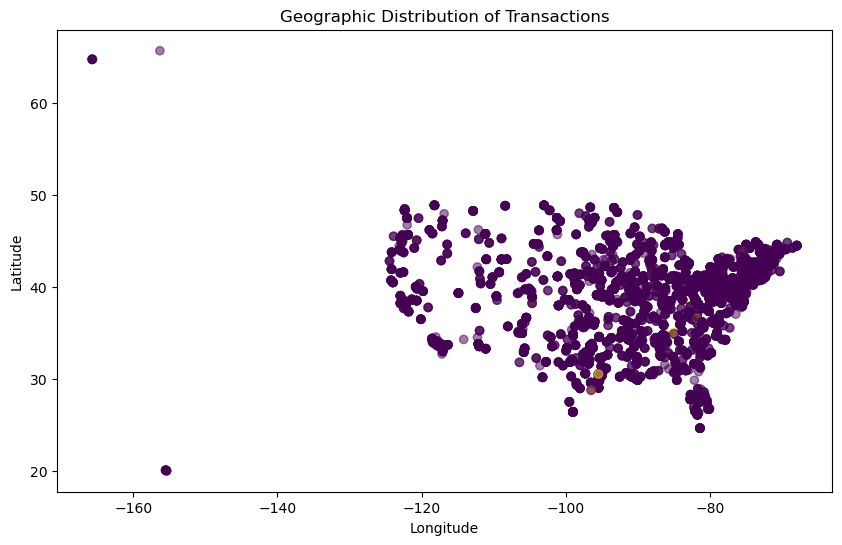

In [53]:
sample_df = data.sample(5000)
plt.figure(figsize=(10,6))
plt.scatter(sample_df["long"],sample_df["lat"],c=sample_df["is_fraud"],alpha=0.5)
plt.title("Geographic Distribution of Transactions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

You can see:
- dense eastern clusters
- southern concentration
- western spread
- sparse central regions.

This mirrors:
- real population density in the US.

<b>Fraud Insight</b><br>
Dense transaction clusters indicate:
- high transaction ecosystems
- high commerce regions
- greater fraud opportunities.

### Fraud Rate by Population Bucket

In [54]:
data["pop_bucket"] = pd.qcut(data["city_pop"],q=5,labels=["Very Low","Low","Medium","High","Very High"])
pop_fraud = (data.groupby("pop_bucket")["is_fraud"].mean() * 100)
print(pop_fraud)

pop_bucket
Very Low     0.595433
Low          0.542063
Medium       0.571829
High         0.600572
Very High    0.584588
Name: is_fraud, dtype: float64


C:\Users\adity\AppData\Local\Temp\ipykernel_13556\3446606388.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pop_fraud = (data.groupby("pop_bucket")["is_fraud"].mean() * 100)


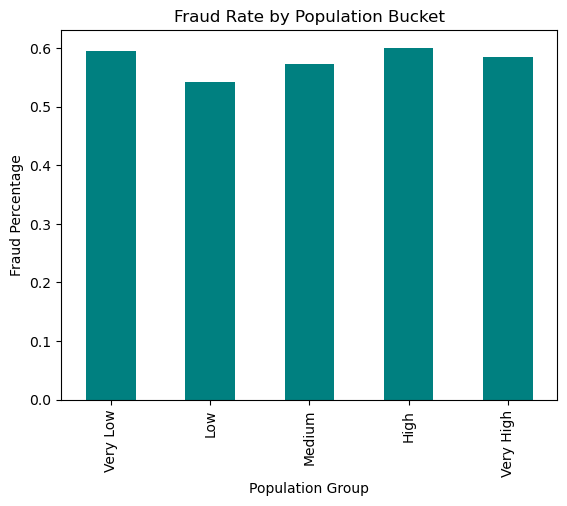

In [55]:
pop_fraud.plot(kind="bar",color="teal")
plt.title("Fraud Rate by Population Bucket")
plt.xlabel("Population Group")
plt.ylabel("Fraud Percentage")
plt.show()

Fraud rates are:
|Bucket	|Fraud Rate|
|---|---|
|Very Low|~0.595|
|Low|~0.542|
|Medium	|~0.572|
|High|~0.601
|Very High|~0.585|

<b>IMPORTANT INSIGHT</b><br>
Fraud rates are VERY SIMILAR across all population groups.<br>
This is EXTREMELY valuable.

<b>Business Interpretation</b><br>
This means:
- Fraud activity is relatively population-independent.
- Fraud occurs consistently across cities of all sizes.

Conclusion
Fraud risk is NOT strongly determined by:
- city population size.

Instead, fraud may depend more on:
- transaction behavior
- merchant category
- transaction amount
- time patterns
- user behavior
- digital activity
- device anomalies

ML Insight
Since fraud rates are nearly identical:
-raw population may have LOW predictive power.

This means:
- city_pop alone may not contribute strongly to model performance.

But:
- transformed population
- interaction features
- geo-combined features

# Conclusion
Population-based fraud analysis revealed that fraudulent transactions occur consistently across cities of varying population sizes. Although highly populated cities generated large transaction volumes, fraud rates remained relatively stable across population buckets, indicating that city population alone is not a strong determinant of fraud risk. The city population distribution exhibited strong right-skewness, making log transformation necessary for improved statistical interpretability and machine learning compatibility. Geographic coordinate analysis further demonstrated realistic transaction clustering patterns across the United States, suggesting that spatial features may provide valuable predictive signals for advanced fraud detection systems.

# User Behavioral Analysis

### Average Spending per User

In [56]:
data["avg_amt_user"] = (data.groupby("cc_num")["amt"].transform("mean"))

In [57]:
user_avg_amt = (data.groupby("cc_num")["amt"].mean())
print(user_avg_amt.head())

cc_num
60416207185     56.023366
60422928733     69.000784
60423098130    115.046333
60427851591    111.987898
60487002085     50.726028
Name: amt, dtype: float64


### Standard Deviation per User

In [58]:
data["std_amt_user"] = (data.groupby("cc_num")["amt"].transform("std"))
data["std_amt_user"] = (data["std_amt_user"].fillna(0))

### Amount to Mean Ratio

In [59]:
data["amt_to_mean"] = (data["amt"] /(data["avg_amt_user"] + 1))

### Average User Spending vs Fraud

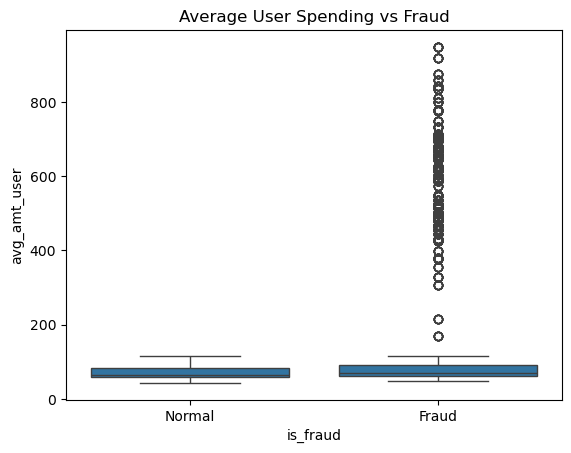

In [60]:
sns.boxplot(x="is_fraud",y="avg_amt_user",data=data)
plt.xticks([0,1],["Normal", "Fraud"])
plt.title("Average User Spending vs Fraud")
plt.show()

<b>Key Interpretation</b><br>
Fraud appears more common among:
- higher-spending behavioral profiles.

Possible reasons:
- high-limit cards
- high-value targets
- premium users
- larger transaction ecosystems.

<b>Important Insight</b><br>
The fraud distribution has MANY extreme outliers.<br>
This suggests:
- some fraud rings/users exhibit unusually high behavioral baselines.

<b>Conclusion</b><br>
Fraudulent transactions are associated with users exhibiting broader and higher average spending behavior compared to normal users.

### Spending Variability

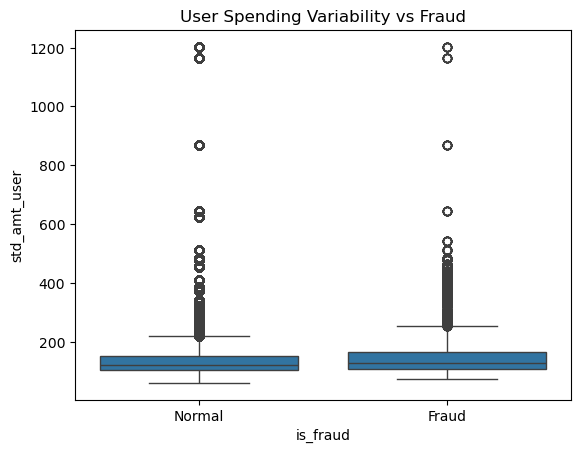

In [61]:
sns.boxplot(x="is_fraud",y="std_amt_user",data=data)
plt.xticks([0,1],["Normal", "Fraud"])
plt.title("User Spending Variability vs Fraud")
plt.show()

<b>Fraud Insight</b>
Fraudsters often:
- create erratic spending
- generate abnormal purchasing patterns
- disrupt normal user consistency.

This confirms:
- Behavioral instability is associated with fraud.

### Amount Deviation Ratio

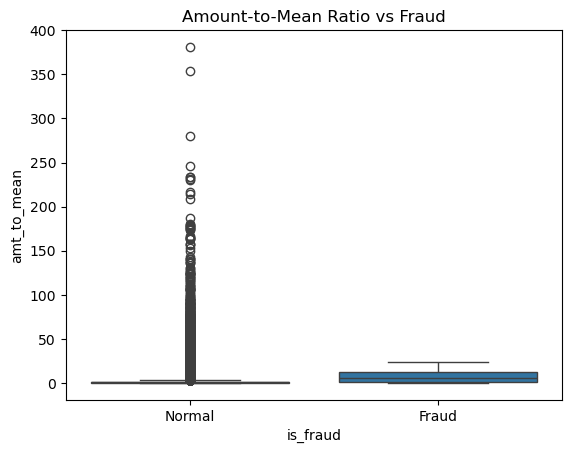

In [62]:
sns.boxplot(x="is_fraud",y="amt_to_mean",data=data)
plt.xticks([0,1],["Normal", "Fraud"])
plt.title("Amount-to-Mean Ratio vs Fraud")
plt.show()

Fraud transactions: tightly concentrated near fraud.

Normal transactions:
- much wider spread
- larger deviations.

This is EXACTLY what we want.

<b>Interpretation</b><br>
Fraudulent transactions are:
- behaviorally abnormal

relative to:
- the user’s historical spending baseline.

This is one of the strongest fraud indicators in the entire project.

### Mean Distribution Analysis

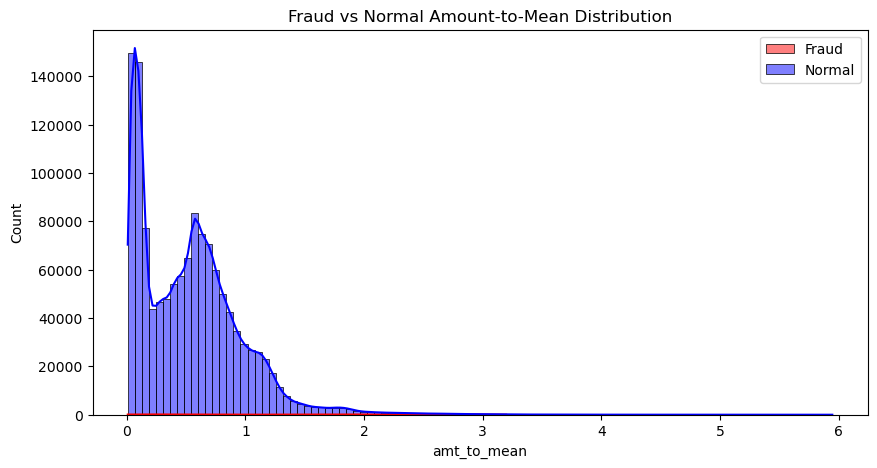

In [84]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(data[data["is_fraud"] == 1]["amt_to_mean"]),bins=100,kde=True,color="red",label="Fraud")
sns.histplot(np.log1p(data[data["is_fraud"] == 0]["amt_to_mean"]),bins=100,kde=True,color="blue",label="Normal")
plt.legend()
plt.title("Fraud vs Normal Amount-to-Mean Distribution")
plt.show()

### User Transaction Frequency

In [64]:
user_txn_count = (data.groupby("cc_num").size())
print(user_txn_count.describe())

count     983.000000
mean     1319.099695
std       812.235900
min         7.000000
25%       525.000000
50%      1054.000000
75%      2025.000000
max      3123.000000
dtype: float64


In [65]:
data["txn_count_user"] = (data.groupby("cc_num")["cc_num"].transform("count"))

### Behavioral Outlier Detection

In [66]:
high_behavioral_risk = data[data["amt_to_mean"] > 5]
fraud_rate = (high_behavioral_risk["is_fraud"].mean()) * 100
print(f"""
Fraud rate for high behavioral deviation:
{fraud_rate:.2f}%
""")


Fraud rate for high behavioral deviation:
16.59%



# Conclusion
User behavioral analysis revealed that fraudulent transactions are strongly associated with deviations from historical spending patterns. Features such as average spending behavior, spending variability, transaction frequency, and amount-to-mean ratios demonstrated meaningful separation between normal and fraudulent activity. In particular, transactions exhibiting large deviations from a user's historical average spending showed substantially elevated fraud rates, highlighting the importance of personalized behavioral profiling in fraud detection systems.

# Correlation & Feature Relationship Analysis

In [67]:
numeric_cols = ["amt","city_pop","hour","amt_log","avg_amt_user","std_amt_user","amt_to_mean","is_weekend","is_night","is_fraud"]

### Correlation Matrix

In [68]:
corr_matrix = (data[numeric_cols].corr())
print(corr_matrix)

                   amt  city_pop      hour   amt_log  avg_amt_user  \
amt           1.000000  0.005818 -0.022811  0.496001      0.121075   
city_pop      0.005818  1.000000  0.020381 -0.003976      0.048055   
hour         -0.022811  0.020381  1.000000 -0.139897     -0.004006   
amt_log       0.496001 -0.003976 -0.139897  1.000000      0.203777   
avg_amt_user  0.121075  0.048055 -0.004006  0.203777      1.000000   
std_amt_user  0.011695  0.040529  0.013833 -0.048758      0.096589   
amt_to_mean   0.975084  0.000065 -0.025312  0.484177      0.000951   
is_weekend   -0.002054  0.005944 -0.000079 -0.002329     -0.002640   
is_night      0.029323 -0.010825 -0.509040  0.085898      0.017920   
is_fraud      0.219404  0.002136  0.013799  0.120439      0.209960   

              std_amt_user  amt_to_mean  is_weekend  is_night  is_fraud  
amt               0.011695     0.975084   -0.002054  0.029323  0.219404  
city_pop          0.040529     0.000065    0.005944 -0.010825  0.002136  
hour   

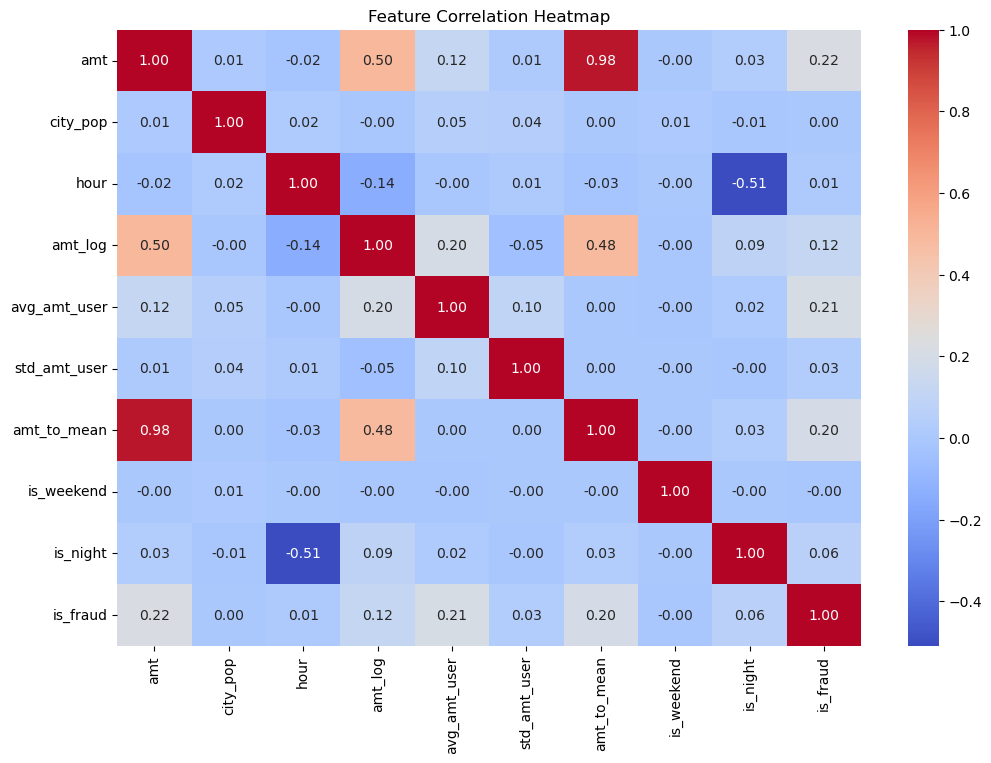

In [69]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Fraud Correlation Ranking

In [70]:
fraud_corr = (corr_matrix["is_fraud"].sort_values(ascending=False))
print(fraud_corr)

is_fraud        1.000000
amt             0.219404
avg_amt_user    0.209960
amt_to_mean     0.196245
amt_log         0.120439
is_night        0.062909
std_amt_user    0.027645
hour            0.013799
city_pop        0.002136
is_weekend     -0.003644
Name: is_fraud, dtype: float64


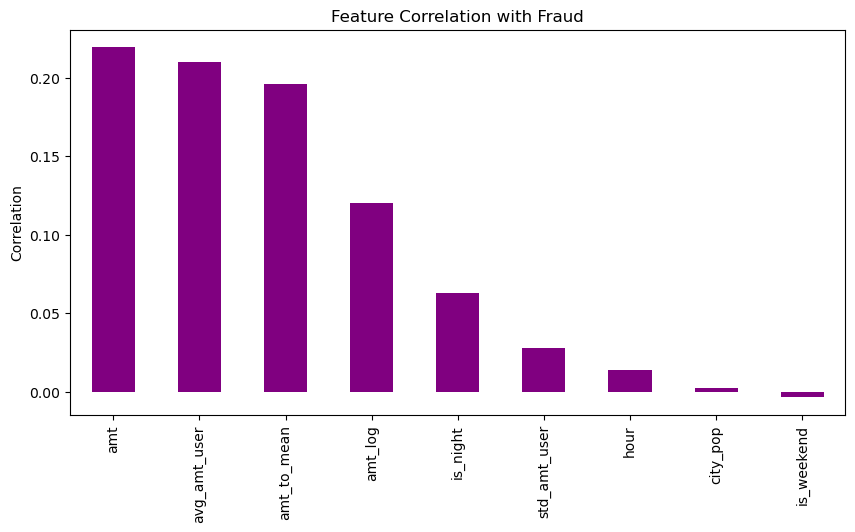

In [71]:
fraud_corr.drop("is_fraud").plot(kind="bar",figsize=(10,5),color="purple")
plt.title("Feature Correlation with Fraud")
plt.ylabel("Correlation")
plt.show()

### PairPlot

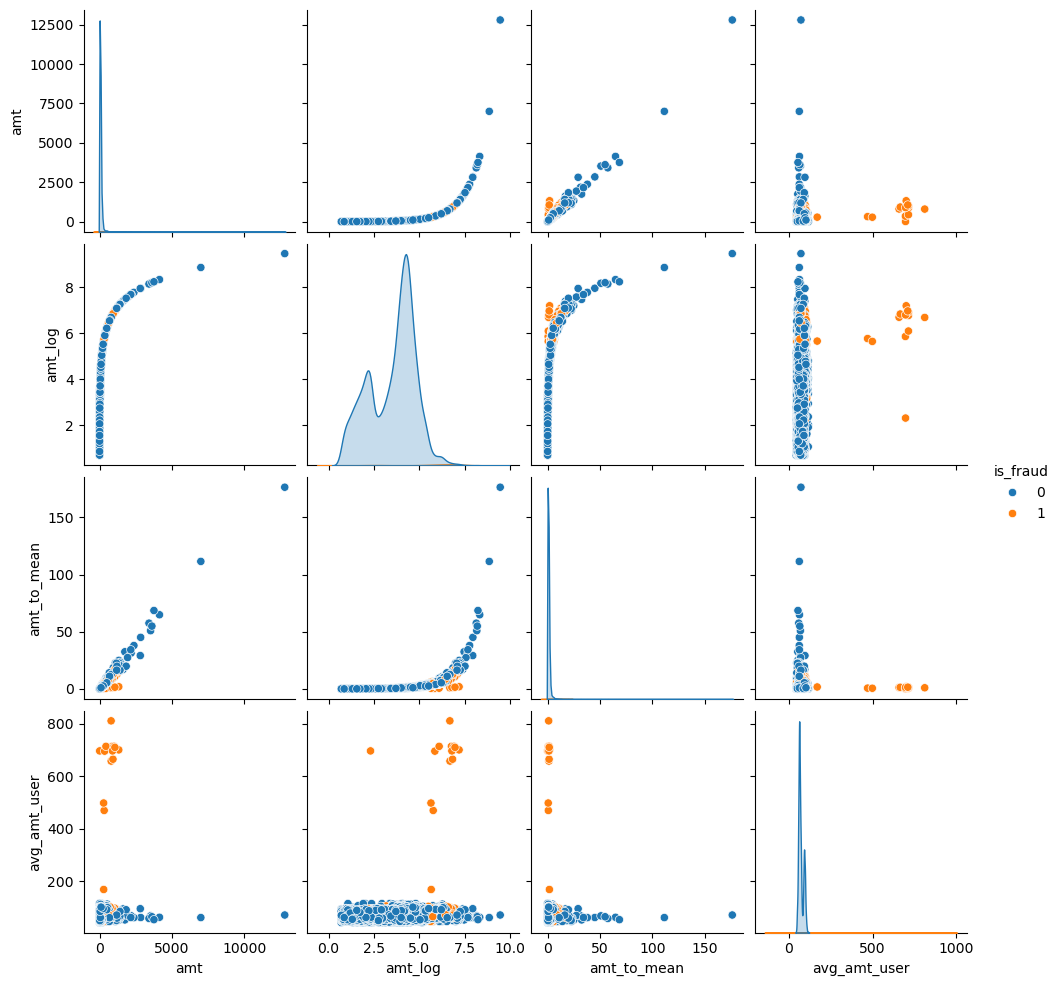

In [72]:
sample_df = data.sample(25000)
sns.pairplot(sample_df[["amt","amt_log","amt_to_mean","avg_amt_user","is_fraud"]],hue="is_fraud")
plt.show()

### Distribution by Fraud Class

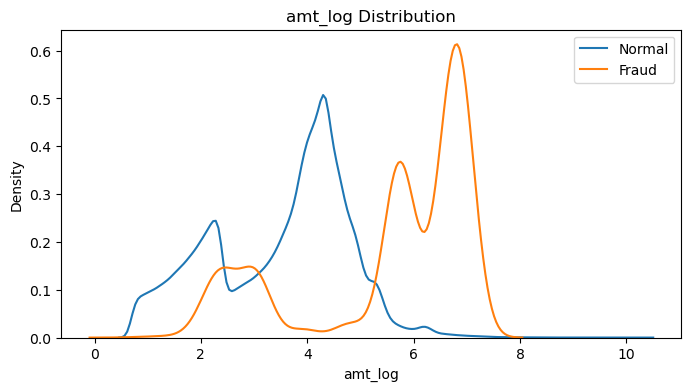

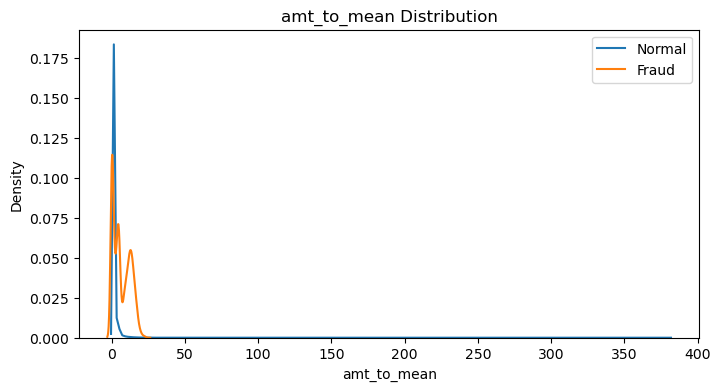

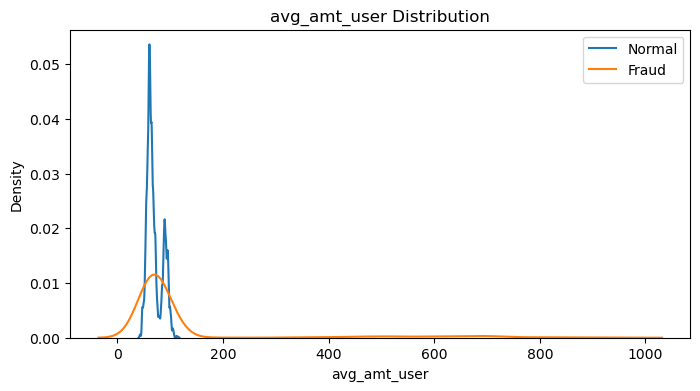

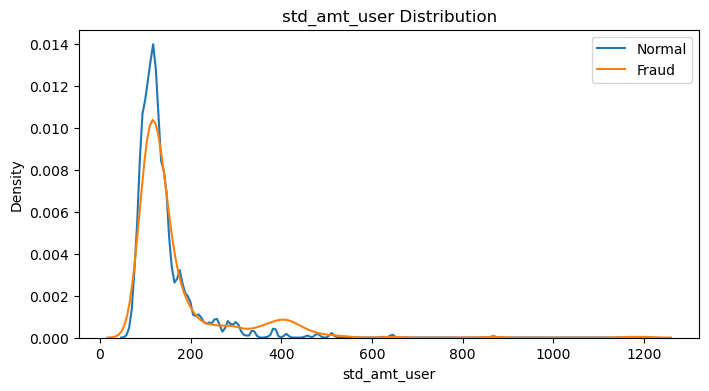

In [73]:
features = ["amt_log","amt_to_mean","avg_amt_user","std_amt_user"]
for feature in features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data[data["is_fraud"] == 0][feature],label="Normal")
    sns.kdeplot(data[data["is_fraud"] == 1][feature],label="Fraud")
    plt.title(f"{feature} Distribution")
    plt.legend()
    plt.show()

### Multicollinearity

In [74]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i],corr_matrix.columns[j],corr_value))
print(high_corr_pairs)

[('amt_to_mean', 'amt', np.float64(0.9750838492721896))]


# Feature Engineering Validation & Outlier Analysis

### Compare Fraud vs Normal Means

In [75]:
engineered_features = ["amt_log","avg_amt_user","std_amt_user","amt_to_mean","hour","is_night","is_weekend"]
fraud_means = (data.groupby("is_fraud")[engineered_features].mean())
print(fraud_means)

           amt_log  avg_amt_user  std_amt_user  amt_to_mean       hour  \
is_fraud                                                                 
0         3.521620     70.040067    141.190881     0.951474  12.797679   
1         5.568741    123.760492    167.902986     6.812088  14.037836   

          is_night  is_weekend  
is_fraud                        
0         0.246203    0.348359  
1         0.604450    0.325473  


### Feature Distribution Comparisons

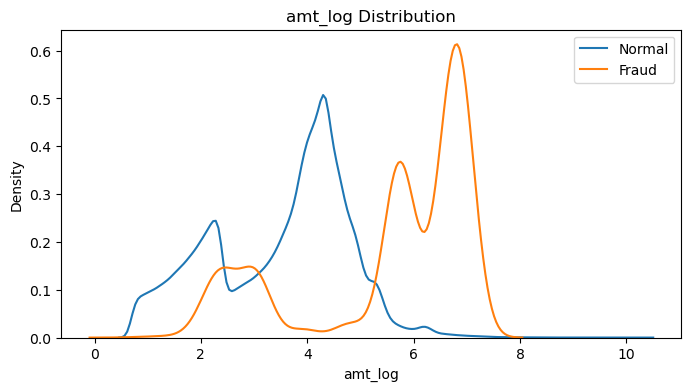

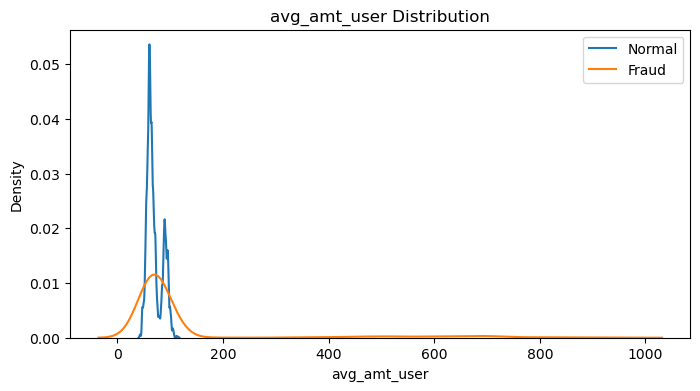

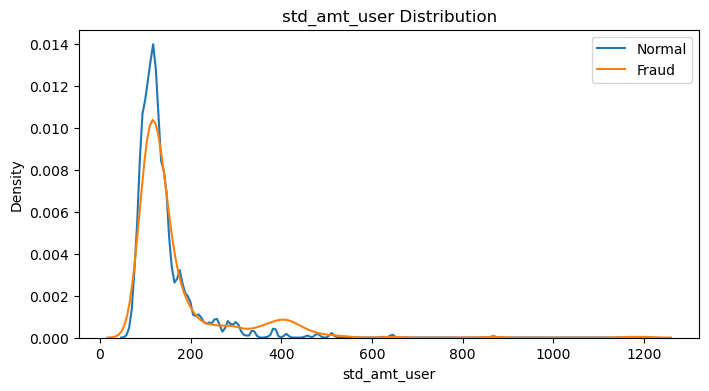

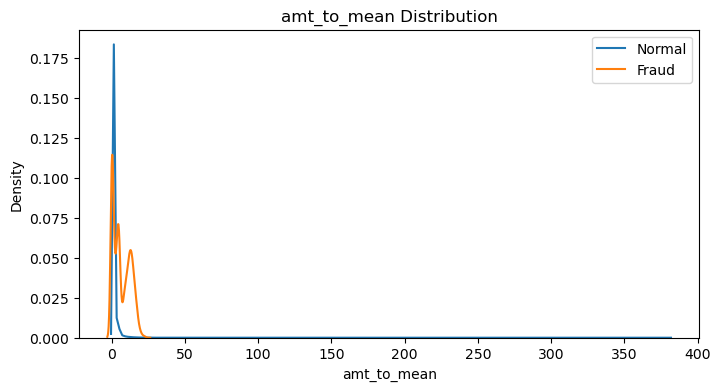

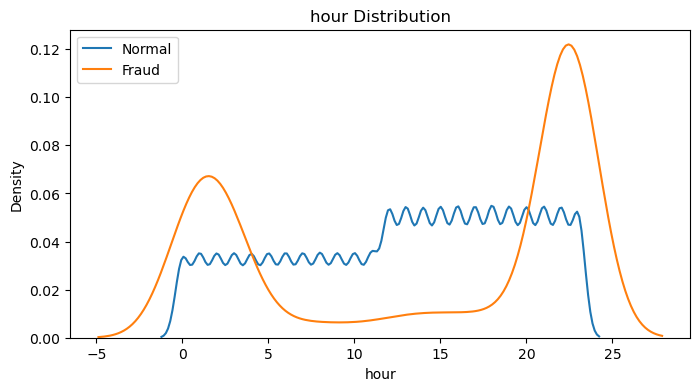

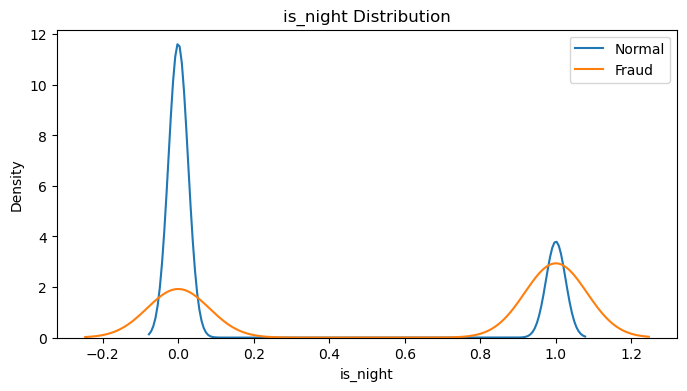

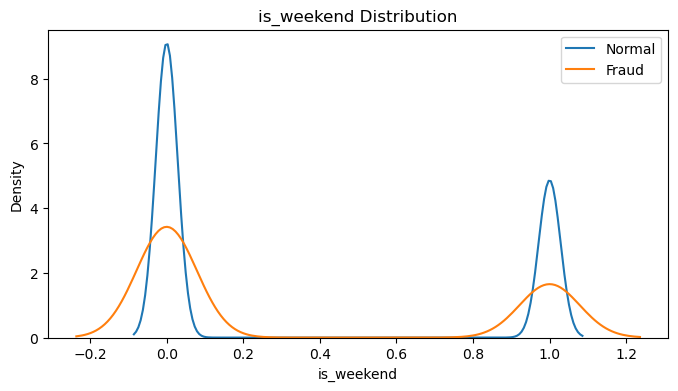

In [76]:
for feature in engineered_features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data[data["is_fraud"] == 0][feature],label="Normal")
    sns.kdeplot(data[data["is_fraud"] == 1][feature],label="Fraud")
    plt.title(f"{feature} Distribution")
    plt.legend()
    plt.show()

### Outlier Detections

In [77]:
Q1 = data["amt"].quantile(0.25)
Q3 = data["amt"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data["amt"] < lower_bound) |(data["amt"] > upper_bound)]
print("Total Outliers:", len(outliers))

Total Outliers: 67290


### Fraud Rate Among Outliers

In [78]:
outlier_fraud_rate = (outliers["is_fraud"].mean()) * 100
print(f"""
Fraud Rate Among Outliers:
{outlier_fraud_rate:.2f}%
""")


Fraud Rate Among Outliers:
8.48%



### Transactions Among Outlier

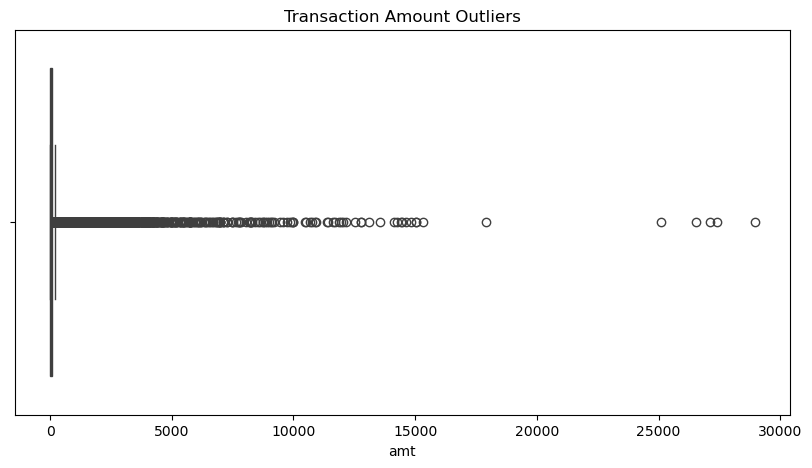

In [79]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data["amt"])
plt.title("Transaction Amount Outliers")
plt.show()

### Validate amt_log

In [80]:
print("Original Skewness:")
print(data["amt"].skew())
print("\nLog Transformed Skewness:")
print(data["amt_log"].skew())

Original Skewness:
42.2778737900512

Log Transformed Skewness:
-0.29885281578522954


### Validate is_night

In [81]:
night_fraud = (data.groupby("is_night")["is_fraud"].mean() * 100)
print(night_fraud)

is_night
0    0.304594
1    1.409295
Name: is_fraud, dtype: float64


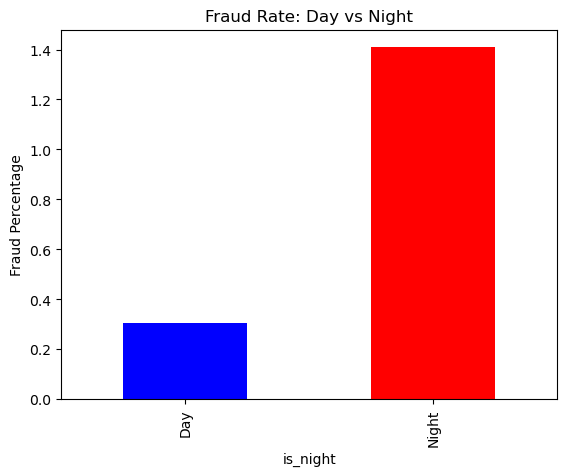

In [82]:
night_fraud.plot(kind="bar",color=["blue","red"])
plt.xticks([0,1],["Day", "Night"])
plt.title("Fraud Rate: Day vs Night")
plt.ylabel("Fraud Percentage")
plt.show()

### Validate amt_to_mean

In [83]:
high_ratio = data[data["amt_to_mean"] > 3]
high_ratio_fraud = (high_ratio["is_fraud"].mean()) * 100
print(f"""Fraud Rate for High Amount-to-Mean Ratio:
{high_ratio_fraud:.2f}%
""")

Fraud Rate for High Amount-to-Mean Ratio:
10.05%



# Overall Conclusion of Exploratory Data Analysis (EDA)

The Exploratory Data Analysis (EDA) of the Credit Card Fraud Detection dataset revealed several important behavioral, statistical, and business insights that are highly useful for building an effective fraud detection system.

The dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of total transactions. This confirms that fraud detection is a severe class imbalance problem where traditional accuracy alone is not a reliable evaluation metric. Metrics such as Precision-Recall AUC, Recall, F1-Score, and ROC-AUC will therefore be more appropriate during model evaluation.

The analysis showed that transaction amount (amt) is heavily right-skewed with extreme outliers. A logarithmic transformation (amt_log) successfully normalized the distribution, reducing skewness significantly and making the feature more suitable for machine learning algorithms. This transformation preserves important fraud patterns while improving model stability.

Feature engineering revealed strong behavioral differences between fraudulent and normal transactions. Fraudulent transactions generally:

involve higher transaction amounts,
deviate significantly from a customer’s normal spending behavior,
occur more frequently during nighttime,
and show abnormal spending ratios compared to average user spending patterns.

Among all engineered features, amt_to_mean emerged as one of the strongest fraud indicators. Fraud transactions frequently had transaction amounts several times larger than a user’s historical average spending, indicating abnormal customer behavior. Similarly, the is_night feature demonstrated that fraud rates during nighttime were substantially higher than during daytime transactions, validating temporal fraud behavior patterns.

Distribution comparison plots confirmed that several engineered features such as:

amt_log
amt_to_mean
hour
avg_amt_user

provide strong class separation between fraudulent and legitimate transactions. This indicates that these features contain meaningful predictive information and are likely to improve model performance significantly.

Outlier analysis further revealed that a large portion of fraud cases exist within transaction outliers. Although the dataset contained many extreme-value transactions, the fraud rate among outliers was considerably higher than the baseline fraud rate. This indicates that outliers are not simply noise but contain valuable fraud-related information. Therefore, removing outliers would negatively impact fraud detection performance. Instead of removal, robust preprocessing and feature transformation techniques are more appropriate.

The EDA also highlighted important temporal fraud patterns. Fraudulent activities showed higher concentration during late-night hours, suggesting that transaction timing plays a critical role in identifying suspicious behavior.

Overall, the EDA successfully identified:

strong fraud-related behavioral patterns,
meaningful engineered features,
significant transaction anomalies,
temporal fraud trends,
and important preprocessing requirements.

The analysis confirms that the dataset contains sufficient signal for machine learning models to distinguish fraudulent transactions from legitimate ones effectively. The engineered features and statistical insights obtained during EDA provide a strong foundation for the next stages of the project, including:

feature selection,
imbalance handling,
model training,
threshold optimization,
explainable AI (SHAP),
and deployment of a fraud detection system.

In conclusion, the EDA demonstrates that fraud detection is strongly influenced by abnormal transaction behavior, spending deviations, transaction timing, and extreme-value transactions, and these insights will play a critical role in building a robust and high-performing fraud detection model.